# Reinforcement Learning Project Part 2
## PPO-Based Continuous Control of a Robotic Arm

### Project Objective

The objective of this project is to train a reinforcement learning agent to control a two-joint robotic arm using Proximal Policy Optimization (PPO).

The project uses the MuJoCo `Reacher-v5` environment, where the agent must learn to apply continuous torque values to two robotic joints so that the fingertip moves toward a randomly positioned target.

The project will evaluate whether PPO can learn an effective and stable continuous-control policy by analyzing:

- Episodic rewards
- Training convergence
- Fingertip-to-target performance
- PPO policy stability
- Value-function learning
- Final evaluation performance

The completed project will also demonstrate the behavior of the trained PPO agent in the robotic simulation.

In [1]:
# ============================================================
# Section 1: Project Setup and Environment Validation
# Import Libraries and Verify Versions
# ============================================================

import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import mujoco

import torch
import torch.nn as nn
import torch.optim as optim

from torch.distributions import Normal


# ------------------------------------------------------------
# Display software environment information
# ------------------------------------------------------------

print("=" * 70)
print("PROJECT ENVIRONMENT")
print("=" * 70)

print(f"Operating System : {platform.system()} {platform.release()}")
print(f"Python Version   : {sys.version.split()[0]}")
print(f"NumPy Version    : {np.__version__}")
print(f"Pandas Version   : {pd.__version__}")
print(f"Gymnasium Version: {gym.__version__}")
print(f"MuJoCo Version   : {mujoco.__version__}")
print(f"PyTorch Version  : {torch.__version__}")

print("-" * 70)

print(f"CUDA Available   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Device      : {torch.cuda.get_device_name(0)}")
else:
    print("Training Device  : CPU")

print("=" * 70)

PROJECT ENVIRONMENT
Operating System : Windows 10
Python Version   : 3.11.9
NumPy Version    : 1.26.4
Pandas Version   : 2.3.3
Gymnasium Version: 1.3.0
MuJoCo Version   : 3.11.0
PyTorch Version  : 2.10.0+cpu
----------------------------------------------------------------------
CUDA Available   : False
Training Device  : CPU


## 2. Reacher-v5 Environment

The project uses the MuJoCo `Reacher-v5` environment from Gymnasium.

The environment contains a two-joint robotic arm operating in a two-dimensional plane. The goal of the agent is to move the fingertip of the robotic arm as close as possible to a randomly positioned target.

This is a continuous-control reinforcement learning problem because the agent does not select from a small set of discrete actions. Instead, it must determine continuous torque values for both robotic joints.

Before implementing PPO, the observation space, action space, episode structure, and initial environment behavior are inspected.

In [2]:
# ============================================================
# Section 2: Create and Inspect the Reacher-v5 Environment
# ============================================================

env = gym.make("Reacher-v5")

print("=" * 70)
print("REACHER-v5 ENVIRONMENT")
print("=" * 70)

print(f"Observation Space : {env.observation_space}")
print(f"Action Space      : {env.action_space}")

print("-" * 70)

print(f"Observation Shape : {env.observation_space.shape}")
print(f"Action Shape      : {env.action_space.shape}")

print(f"Number of States  : {env.observation_space.shape[0]}")
print(f"Number of Actions : {env.action_space.shape[0]}")

print("-" * 70)

print(f"Action Lower Bound: {env.action_space.low}")
print(f"Action Upper Bound: {env.action_space.high}")

print(f"Maximum Episode Steps: {env.spec.max_episode_steps}")

print("=" * 70)

REACHER-v5 ENVIRONMENT
Observation Space : Box(-inf, inf, (10,), float64)
Action Space      : Box(-1.0, 1.0, (2,), float32)
----------------------------------------------------------------------
Observation Shape : (10,)
Action Shape      : (2,)
Number of States  : 10
Number of Actions : 2
----------------------------------------------------------------------
Action Lower Bound: [-1. -1.]
Action Upper Bound: [1. 1.]
Maximum Episode Steps: 50


## 3. Understanding the Observation Vector

The `Reacher-v5` environment returns a 10-dimensional continuous observation vector.

The observation contains information about:

- The cosine of the two joint angles
- The sine of the two joint angles
- The x and y coordinates of the target
- The angular velocities of the two joints
- The x and y displacement between the fingertip and the target

These values provide the PPO agent with the information required to determine how the robotic arm should move toward the target.

In [4]:
# ============================================================
# Section 3: Reset Environment and Inspect Initial Observation
# ============================================================

observation, info = env.reset(seed=42)

observation_labels = [
    "cos(joint_0)",
    "cos(joint_1)",
    "sin(joint_0)",
    "sin(joint_1)",
    "target_x",
    "target_y",
    "joint_0_velocity",
    "joint_1_velocity",
    "fingertip_minus_target_x",
    "fingertip_minus_target_y"
]

observation_df = pd.DataFrame({
    "Observation": observation_labels,
    "Value": observation
})

print("=" * 70)
print("INITIAL REACHER-v5 OBSERVATION")
print("=" * 70)

print(observation_df.to_string(index=False))

print("-" * 70)

print(f"Observation Shape : {observation.shape}")
print(f"Observation Dtype : {observation.dtype}")
print(f"Info Dictionary   : {info}")

print("=" * 70)

INITIAL REACHER-v5 OBSERVATION
             Observation     Value
            cos(joint_0)  0.998499
            cos(joint_1)  0.999925
            sin(joint_0)  0.054764
            sin(joint_1) -0.012224
                target_x  0.104456
                target_y  0.114426
        joint_0_velocity -0.003719
        joint_1_velocity -0.000496
fingertip_minus_target_x  0.105294
fingertip_minus_target_y -0.104268
----------------------------------------------------------------------
Observation Shape : (10,)
Observation Dtype : float64
Info Dictionary   : {}


## 4. Understanding One Environment Interaction

Reinforcement learning is based on repeated interaction between an agent and its environment.

At each timestep:

1. The agent observes the current state.
2. The agent selects an action.
3. The environment applies the action.
4. The environment returns a reward and the next observation.
5. The process repeats until the episode ends.

Before implementing PPO, a single zero-torque action is applied to the Reacher environment to examine this interaction directly.

In [5]:
# ============================================================
# Section 4: Examine One RL Environment Interaction
# ============================================================

# Reset so this experiment starts from a known state
state, info = env.reset(seed=42)

# ------------------------------------------------------------
# Inspect initial fingertip-to-target displacement
# ------------------------------------------------------------

initial_displacement = state[-2:]
initial_distance = np.linalg.norm(initial_displacement)

print("=" * 70)
print("BEFORE ACTION")
print("=" * 70)

print(f"Fingertip-target X displacement : {initial_displacement[0]:.6f}")
print(f"Fingertip-target Y displacement : {initial_displacement[1]:.6f}")
print(f"Fingertip-target distance       : {initial_distance:.6f}")

# ------------------------------------------------------------
# Apply zero torque to both joints
# ------------------------------------------------------------

action = np.array([0.0, 0.0], dtype=np.float32)

next_state, reward, terminated, truncated, info = env.step(action)

# ------------------------------------------------------------
# Inspect resulting state
# ------------------------------------------------------------

next_displacement = next_state[-2:]
next_distance = np.linalg.norm(next_displacement)

print("\n" + "=" * 70)
print("ACTION")
print("=" * 70)

print(f"Action applied : {action}")

print("\n" + "=" * 70)
print("AFTER ACTION")
print("=" * 70)

print(f"Fingertip-target X displacement : {next_displacement[0]:.6f}")
print(f"Fingertip-target Y displacement : {next_displacement[1]:.6f}")
print(f"Fingertip-target distance       : {next_distance:.6f}")

print("\n" + "=" * 70)
print("REWARD AND EPISODE INFORMATION")
print("=" * 70)

print(f"Reward       : {reward:.6f}")
print(f"Terminated   : {terminated}")
print(f"Truncated    : {truncated}")
print(f"Info         : {info}")

print("=" * 70)

BEFORE ACTION
Fingertip-target X displacement : 0.105294
Fingertip-target Y displacement : -0.104268
Fingertip-target distance       : 0.148185

ACTION
Action applied : [0. 0.]

AFTER ACTION
Fingertip-target X displacement : 0.105295
Fingertip-target Y displacement : -0.104285
Fingertip-target distance       : 0.148197

REWARD AND EPISODE INFORMATION
Reward       : -0.148197
Terminated   : False
Truncated    : False
Info         : {'reward_dist': -0.14819725122506736, 'reward_ctrl': -0.0}


## 5. Random-Agent Baseline

Before training the PPO agent, a random-action policy is evaluated to establish a baseline.

The random agent selects actions directly from the valid continuous action space without learning from previous experience.

This baseline provides a useful reference for evaluating whether the trained PPO agent produces meaningful improvement.

For each episode, the following metrics are recorded:

- Total episodic reward
- Mean fingertip-to-target distance
- Final fingertip-to-target distance
- Mean control cost
- Number of timesteps

The trained PPO agent will later be evaluated using the same measurements.

In [6]:
# ============================================================
# Section 5: Random-Agent Baseline Evaluation
# ============================================================

NUM_BASELINE_EPISODES = 100

baseline_results = []


for episode in range(NUM_BASELINE_EPISODES):

    state, info = env.reset(seed=1000 + episode)

    episode_reward = 0.0
    distances = []
    control_costs = []
    steps = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Random continuous action
        action = env.action_space.sample()

        # Environment interaction
        next_state, reward, terminated, truncated, info = env.step(action)

        # Distance between fingertip and target
        distance = np.linalg.norm(next_state[-2:])

        # Record metrics
        episode_reward += reward
        distances.append(distance)
        control_costs.append(abs(info["reward_ctrl"]))

        steps += 1
        state = next_state

    baseline_results.append({
        "Episode": episode + 1,
        "Total Reward": episode_reward,
        "Mean Distance": np.mean(distances),
        "Final Distance": distances[-1],
        "Mean Control Cost": np.mean(control_costs),
        "Steps": steps
    })


# Convert results to DataFrame
baseline_df = pd.DataFrame(baseline_results)


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 70)
print("RANDOM-AGENT BASELINE")
print("=" * 70)

print(f"Episodes                : {NUM_BASELINE_EPISODES}")
print(f"Mean Episode Reward     : {baseline_df['Total Reward'].mean():.4f}")
print(f"Median Episode Reward   : {baseline_df['Total Reward'].median():.4f}")
print(f"Reward Standard Dev.    : {baseline_df['Total Reward'].std():.4f}")
print(f"Best Episode Reward     : {baseline_df['Total Reward'].max():.4f}")
print(f"Worst Episode Reward    : {baseline_df['Total Reward'].min():.4f}")

print("-" * 70)

print(f"Mean Target Distance    : {baseline_df['Mean Distance'].mean():.4f}")
print(f"Mean Final Distance     : {baseline_df['Final Distance'].mean():.4f}")
print(f"Mean Control Cost       : {baseline_df['Mean Control Cost'].mean():.4f}")
print(f"Mean Episode Length     : {baseline_df['Steps'].mean():.1f}")

print("=" * 70)


# Display first few episodes
display(baseline_df.head(10))

RANDOM-AGENT BASELINE
Episodes                : 100
Mean Episode Reward     : -42.8072
Median Episode Reward   : -42.4546
Reward Standard Dev.    : 4.1327
Best Episode Reward     : -33.4800
Worst Episode Reward    : -53.1123
----------------------------------------------------------------------
Mean Target Distance    : 0.1857
Mean Final Distance     : 0.1669
Mean Control Cost       : 0.6705
Mean Episode Length     : 50.0


,Episode,Total Reward,Mean Distance,Final Distance,Mean Control Cost,Steps
0,1,-43.134825,0.197923,0.074239,0.664774,50
1,2,-42.194023,0.208338,0.304221,0.635543,50
2,3,-39.657094,0.157397,0.202371,0.635745,50
3,4,-34.723157,0.111112,0.131982,0.583351,50
4,5,-52.452566,0.201705,0.134529,0.847346,50
5,6,-39.145738,0.195741,0.052599,0.587173,50
6,7,-33.480018,0.119227,0.159351,0.550374,50
7,8,-46.439929,0.264263,0.204985,0.664536,50
8,9,-47.174497,0.269472,0.198308,0.674018,50
9,10,-44.353320,0.215626,0.194404,0.671441,50


## 6. Random-Agent Baseline Analysis

The random-agent experiment establishes the performance expected without reinforcement learning.

Across 100 episodes, the random policy achieved a mean episodic reward of approximately -42.8. The agent also maintained an average fingertip-to-target distance of approximately 0.186 while using relatively large random joint torques.

These values provide the baseline against which the trained PPO policy will later be evaluated.

The complete episode-level results and summary statistics are saved as project artifacts for later comparison.

In [7]:
# ============================================================
# Section 6: Save Random-Agent Baseline Results
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# Define project output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Save episode-level baseline results
# ------------------------------------------------------------

baseline_metrics_path = OUTPUT_DIR / "random_baseline_metrics.csv"

baseline_df.to_csv(
    baseline_metrics_path,
    index=False
)


# ------------------------------------------------------------
# Create baseline summary
# ------------------------------------------------------------

baseline_summary = pd.DataFrame({
    "Metric": [
        "Episodes",
        "Mean Episode Reward",
        "Median Episode Reward",
        "Reward Standard Deviation",
        "Best Episode Reward",
        "Worst Episode Reward",
        "Mean Target Distance",
        "Mean Final Distance",
        "Mean Control Cost",
        "Mean Episode Length"
    ],

    "Value": [
        NUM_BASELINE_EPISODES,
        baseline_df["Total Reward"].mean(),
        baseline_df["Total Reward"].median(),
        baseline_df["Total Reward"].std(),
        baseline_df["Total Reward"].max(),
        baseline_df["Total Reward"].min(),
        baseline_df["Mean Distance"].mean(),
        baseline_df["Final Distance"].mean(),
        baseline_df["Mean Control Cost"].mean(),
        baseline_df["Steps"].mean()
    ]
})


baseline_summary_path = OUTPUT_DIR / "random_baseline_summary.csv"

baseline_summary.to_csv(
    baseline_summary_path,
    index=False
)


# ------------------------------------------------------------
# Confirm saved artifacts
# ------------------------------------------------------------

print("=" * 70)
print("BASELINE ARTIFACTS SAVED")
print("=" * 70)

print(f"Episode Metrics : {baseline_metrics_path}")
print(f"Summary Metrics : {baseline_summary_path}")

print("=" * 70)

display(baseline_summary)

BASELINE ARTIFACTS SAVED
Episode Metrics : outputs\random_baseline_metrics.csv
Summary Metrics : outputs\random_baseline_summary.csv


,Metric,Value
0,Episodes,100.000000
1,Mean Episode Reward,-42.807213
2,Median Episode Reward,-42.454570
3,Reward Standard Deviation,4.132676
4,Best Episode Reward,-33.480018
5,Worst Episode Reward,-53.112272
6,Mean Target Distance,0.185685
7,Mean Final Distance,0.166922
8,Mean Control Cost,0.670459
9,Mean Episode Length,50.000000


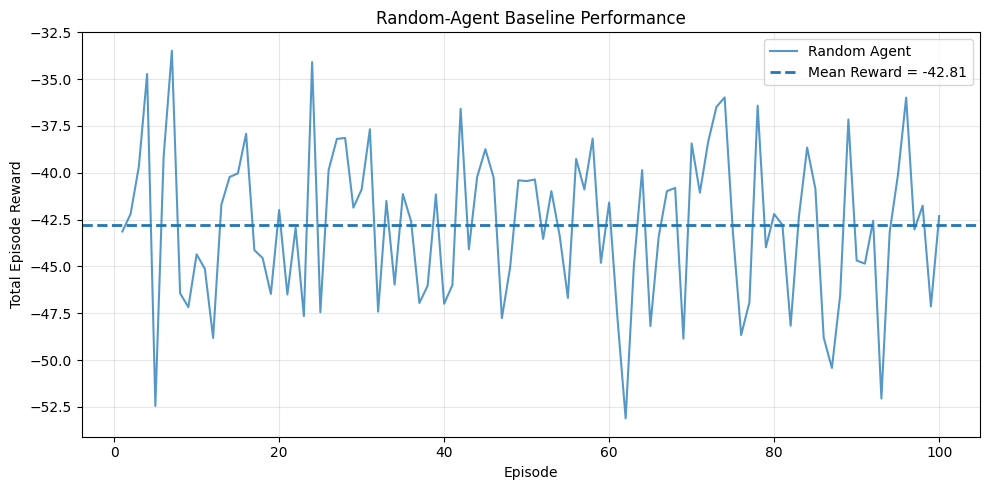

Saved plot: outputs\random_baseline_rewards.png


In [8]:
# ============================================================
# Random-Agent Baseline Reward Visualization
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    baseline_df["Episode"],
    baseline_df["Total Reward"],
    alpha=0.75,
    label="Random Agent"
)

plt.axhline(
    baseline_df["Total Reward"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean Reward = {baseline_df['Total Reward'].mean():.2f}"
)

plt.xlabel("Episode")
plt.ylabel("Total Episode Reward")
plt.title("Random-Agent Baseline Performance")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

baseline_plot_path = OUTPUT_DIR / "random_baseline_rewards.png"

plt.savefig(
    baseline_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(f"Saved plot: {baseline_plot_path}")

## 7. PPO Configuration and Hyperparameters

Proximal Policy Optimization (PPO) improves a policy by repeatedly collecting experience from the environment and updating an actor-critic neural network.

The following hyperparameters control the major parts of the learning process:

- **Learning rate:** Controls the size of neural-network parameter updates.
- **Discount factor (gamma):** Determines how strongly future rewards influence current decisions.
- **GAE lambda:** Controls the bias-variance tradeoff when estimating advantages.
- **PPO clip epsilon:** Restricts how much the policy is allowed to change during one update.
- **Rollout size:** Number of environment interactions collected before each PPO update.
- **Minibatch size:** Number of samples processed during each optimization step.
- **PPO epochs:** Number of times the collected rollout data is reused during an update.
- **Entropy coefficient:** Encourages exploration by preventing the policy from becoming deterministic too quickly.
- **Value coefficient:** Determines the contribution of critic loss to the overall optimization objective.
- **Maximum gradient norm:** Limits very large gradient updates and improves training stability.

These values provide a reasonable starting configuration for the Reacher-v5 continuous-control task.

In [9]:
# ============================================================
# Section 7: PPO Configuration and Hyperparameters
# ============================================================

# Reproducibility
SEED = 42

# Neural-network optimization
LEARNING_RATE = 3e-4

# Reinforcement-learning parameters
GAMMA = 0.99
GAE_LAMBDA = 0.95

# PPO parameters
CLIP_EPSILON = 0.20
ROLLOUT_STEPS = 1024
MINIBATCH_SIZE = 64
PPO_EPOCHS = 10

# Loss coefficients
ENTROPY_COEF = 0.01
VALUE_COEF = 0.50

# Training stability
MAX_GRAD_NORM = 0.50


# ------------------------------------------------------------
# Training device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# Create hyperparameter table
# ------------------------------------------------------------

ppo_config = pd.DataFrame({
    "Hyperparameter": [
        "Random Seed",
        "Learning Rate",
        "Discount Factor (Gamma)",
        "GAE Lambda",
        "PPO Clip Epsilon",
        "Rollout Steps",
        "Minibatch Size",
        "PPO Epochs",
        "Entropy Coefficient",
        "Value Coefficient",
        "Maximum Gradient Norm",
        "Training Device"
    ],

    "Value": [
        SEED,
        LEARNING_RATE,
        GAMMA,
        GAE_LAMBDA,
        CLIP_EPSILON,
        ROLLOUT_STEPS,
        MINIBATCH_SIZE,
        PPO_EPOCHS,
        ENTROPY_COEF,
        VALUE_COEF,
        MAX_GRAD_NORM,
        str(device)
    ]
})


print("=" * 70)
print("PPO TRAINING CONFIGURATION")
print("=" * 70)

display(ppo_config)

print("=" * 70)

PPO TRAINING CONFIGURATION


,Hyperparameter,Value
0,Random Seed,42
1,Learning Rate,0.0003
2,Discount Factor (Gamma),0.99
3,GAE Lambda,0.95
4,PPO Clip Epsilon,0.2
5,Rollout Steps,1024
6,Minibatch Size,64
7,PPO Epochs,10
8,Entropy Coefficient,0.01
9,Value Coefficient,0.5


## 8. PPO Actor-Critic Neural Network

PPO uses an actor-critic architecture containing two related function approximators.

### Actor

The actor represents the policy. It receives the 10-dimensional Reacher observation and produces parameters for a continuous probability distribution over the two joint-control actions.

Because the action space is continuous, the policy is represented using Gaussian distributions rather than discrete action probabilities.

### Critic

The critic estimates the state-value function, \(V(s)\), which represents the expected future return from the current state.

The value estimate is used when calculating temporal-difference errors and generalized advantage estimates.

### Network Architecture

Both networks use two hidden layers containing 64 neurons with Tanh activation functions.

- Actor: 10 → 64 → 64 → 2
- Critic: 10 → 64 → 64 → 1

The actor also contains a learnable log-standard-deviation parameter that controls exploration in the continuous action space.

In [10]:
# ============================================================
# Section 8: PPO Actor-Critic Neural Network
# ============================================================

class ActorCritic(nn.Module):

    def __init__(self, state_dim, action_dim):

        super().__init__()

        # ----------------------------------------------------
        # Actor network
        # ----------------------------------------------------

        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, action_dim)
        )

        # Learnable log standard deviation for each action
        self.actor_log_std = nn.Parameter(
            torch.zeros(action_dim)
        )

        # ----------------------------------------------------
        # Critic network
        # ----------------------------------------------------

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )


    def forward(self, state):
        """
        Returns:
            action_mean : Mean of Gaussian policy
            action_std  : Standard deviation of Gaussian policy
            state_value : Critic estimate V(s)
        """

        action_mean = self.actor(state)

        action_std = torch.exp(
            self.actor_log_std
        ).expand_as(action_mean)

        state_value = self.critic(state)

        return action_mean, action_std, state_value

In [11]:
# ============================================================
# Instantiate and Validate the Actor-Critic Network
# ============================================================

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = ActorCritic(
    state_dim=state_dim,
    action_dim=action_dim
).to(device)


# ------------------------------------------------------------
# Test model using a real Reacher observation
# ------------------------------------------------------------

test_state, _ = env.reset(seed=SEED)

test_state_tensor = torch.tensor(
    test_state,
    dtype=torch.float32,
    device=device
).unsqueeze(0)


with torch.no_grad():

    action_mean, action_std, state_value = model(
        test_state_tensor
    )


# ------------------------------------------------------------
# Count model parameters
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("ACTOR-CRITIC NETWORK VALIDATION")
print("=" * 70)

print(f"State Dimension       : {state_dim}")
print(f"Action Dimension      : {action_dim}")

print("-" * 70)

print(f"Input Tensor Shape    : {test_state_tensor.shape}")
print(f"Action Mean Shape     : {action_mean.shape}")
print(f"Action Std Shape      : {action_std.shape}")
print(f"State Value Shape     : {state_value.shape}")

print("-" * 70)

print(f"Initial Action Mean   : {action_mean.cpu().numpy().flatten()}")
print(f"Initial Action Std    : {action_std.cpu().numpy().flatten()}")
print(f"Initial State Value   : {state_value.item():.6f}")

print("-" * 70)

print(f"Total Parameters      : {total_parameters:,}")
print(f"Trainable Parameters  : {trainable_parameters:,}")

print("=" * 70)

print("\nMODEL ARCHITECTURE")
print(model)

ACTOR-CRITIC NETWORK VALIDATION
State Dimension       : 10
Action Dimension      : 2
----------------------------------------------------------------------
Input Tensor Shape    : torch.Size([1, 10])
Action Mean Shape     : torch.Size([1, 2])
Action Std Shape      : torch.Size([1, 2])
State Value Shape     : torch.Size([1, 1])
----------------------------------------------------------------------
Initial Action Mean   : [0.29948822 0.20270757]
Initial Action Std    : [1. 1.]
Initial State Value   : -0.096664
----------------------------------------------------------------------
Total Parameters      : 9,925
Trainable Parameters  : 9,925

MODEL ARCHITECTURE
ActorCritic(
  (actor): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)


In [12]:
# ============================================================
# Compact Actor-Critic Validation Summary
# ============================================================

print("=" * 60)
print("ACTOR-CRITIC VALIDATION SUMMARY")
print("=" * 60)

print(f"State Dimension    : {state_dim}")
print(f"Action Dimension   : {action_dim}")

print(f"Input Shape        : {tuple(test_state_tensor.shape)}")
print(f"Action Mean Shape  : {tuple(action_mean.shape)}")
print(f"Action Std Shape   : {tuple(action_std.shape)}")
print(f"State Value Shape  : {tuple(state_value.shape)}")

print("-" * 60)

print(f"Initial Action Mean: {action_mean.cpu().numpy().flatten()}")
print(f"Initial Action Std : {action_std.cpu().numpy().flatten()}")
print(f"Initial State Value: {state_value.item():.6f}")

print("-" * 60)

print(f"Total Parameters   : {total_parameters:,}")
print(f"Trainable Params   : {trainable_parameters:,}")

print("=" * 60)

ACTOR-CRITIC VALIDATION SUMMARY
State Dimension    : 10
Action Dimension   : 2
Input Shape        : (1, 10)
Action Mean Shape  : (1, 2)
Action Std Shape   : (1, 2)
State Value Shape  : (1, 1)
------------------------------------------------------------
Initial Action Mean: [0.29948822 0.20270757]
Initial Action Std : [1. 1.]
Initial State Value: -0.096664
------------------------------------------------------------
Total Parameters   : 9,925
Trainable Params   : 9,925


## 9. Continuous Action Sampling

The PPO actor represents a stochastic policy for the continuous Reacher action space.

For each observation, the actor produces the mean of a Gaussian distribution for each of the two joint torques. A learnable standard deviation controls the amount of exploration.

An action is sampled from these Gaussian distributions and then constrained to the valid Reacher action range of -1 to 1.

The log probability of the sampled action is also recorded. PPO later compares the probability of actions under the old and updated policies when calculating its clipped policy objective.

In [13]:
# ============================================================
# Section 9: Sample a Continuous Action from the PPO Policy
# ============================================================

state, _ = env.reset(seed=SEED)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32,
    device=device
).unsqueeze(0)


with torch.no_grad():

    # Actor and critic outputs
    action_mean, action_std, state_value = model(state_tensor)

    # Create Gaussian action distribution
    distribution = Normal(
        action_mean,
        action_std
    )

    # Sample action
    sampled_action = distribution.sample()

    # Log probability of sampled action
    log_prob = distribution.log_prob(
        sampled_action
    ).sum(dim=-1)

    # Clip action to valid Reacher range
    clipped_action = torch.clamp(
        sampled_action,
        -1.0,
        1.0
    )


# ------------------------------------------------------------
# Convert to NumPy for environment interaction
# ------------------------------------------------------------

action_np = clipped_action.cpu().numpy().flatten()


# ------------------------------------------------------------
# Display policy outputs
# ------------------------------------------------------------

print("=" * 70)
print("CONTINUOUS POLICY ACTION SAMPLING")
print("=" * 70)

print(
    f"Action Mean        : "
    f"{action_mean.cpu().numpy().flatten()}"
)

print(
    f"Action Std         : "
    f"{action_std.cpu().numpy().flatten()}"
)

print(
    f"Raw Sampled Action : "
    f"{sampled_action.cpu().numpy().flatten()}"
)

print(
    f"Clipped Action     : "
    f"{action_np}"
)

print(
    f"Log Probability    : "
    f"{log_prob.item():.6f}"
)

print(
    f"State Value        : "
    f"{state_value.item():.6f}"
)

print("=" * 70)

CONTINUOUS POLICY ACTION SAMPLING
Action Mean        : [0.29948822 0.20270757]
Action Std         : [1. 1.]
Raw Sampled Action : [-1.1376809   0.23214084]
Clipped Action     : [-1.          0.23214084]
Log Probability    : -2.871038
State Value        : -0.096664


## 10. Reusable PPO Action Selection

During training, the PPO agent must select actions thousands of times. A reusable action-selection function is therefore created to perform the complete policy interaction consistently.

The function:

1. Converts the environment observation into a PyTorch tensor.
2. Passes the observation through the actor and critic.
3. Creates the Gaussian policy distribution.
4. Samples a continuous action.
5. Applies a Tanh transformation to constrain the action to the valid range.
6. Records the action log probability.
7. Records the critic's state-value estimate.

The raw Gaussian action is retained for PPO optimization, while the bounded action is sent to the Reacher environment.

In [14]:
# ============================================================
# Section 10: Reusable PPO Action-Selection Function
# ============================================================

def select_action(model, state, deterministic=False):
    """
    Select an action using the PPO actor-critic model.

    Parameters
    ----------
    model : ActorCritic
        PPO actor-critic neural network.

    state : np.ndarray
        Current Reacher observation.

    deterministic : bool
        If False, sample from the Gaussian policy.
        If True, use the policy mean.

    Returns
    -------
    env_action : np.ndarray
        Bounded action sent to Reacher.

    raw_action : np.ndarray
        Unbounded Gaussian action used for PPO calculations.

    log_prob : float
        Log probability of the raw action.

    state_value : float
        Critic estimate V(s).
    """

    # Convert observation to PyTorch tensor
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():

        # Actor and critic predictions
        action_mean, action_std, state_value = model(
            state_tensor
        )

        # Gaussian policy
        distribution = Normal(
            action_mean,
            action_std
        )

        # ----------------------------------------------------
        # Select action
        # ----------------------------------------------------

        if deterministic:
            raw_action = action_mean
        else:
            raw_action = distribution.sample()

        # Log probability used later by PPO
        log_prob = distribution.log_prob(
            raw_action
        ).sum(dim=-1)

        # Smoothly constrain action to (-1, 1)
        bounded_action = torch.tanh(raw_action)

    # --------------------------------------------------------
    # Convert outputs to NumPy / Python values
    # --------------------------------------------------------

    env_action = (
        bounded_action
        .cpu()
        .numpy()
        .flatten()
        .astype(np.float32)
    )

    raw_action_np = (
        raw_action
        .cpu()
        .numpy()
        .flatten()
    )

    return (
        env_action,
        raw_action_np,
        log_prob.item(),
        state_value.item()
    )

In [15]:
# ============================================================
# Validate Reusable Action Selection
# ============================================================

test_state, _ = env.reset(seed=SEED)

(
    test_env_action,
    test_raw_action,
    test_log_prob,
    test_value
) = select_action(
    model,
    test_state
)


print("=" * 70)
print("SELECT_ACTION() VALIDATION")
print("=" * 70)

print(f"Raw Gaussian Action : {test_raw_action}")
print(f"Bounded Env Action  : {test_env_action}")
print(f"Action Log Prob     : {test_log_prob:.6f}")
print(f"Critic State Value  : {test_value:.6f}")

print("-" * 70)

print(
    "Action Within Bounds:",
    np.all(test_env_action >= env.action_space.low)
    and
    np.all(test_env_action <= env.action_space.high)
)

print("=" * 70)

SELECT_ACTION() VALIDATION
Raw Gaussian Action : [1.0081186 0.3147601]
Bounded Env Action  : [0.76498276 0.30476132]
Action Log Prob     : -2.095233
Critic State Value  : -0.096664
----------------------------------------------------------------------
Action Within Bounds: True


## 11. PPO Rollout Collection

PPO is an on-policy reinforcement learning algorithm. Before updating the neural network, the current policy interacts with the environment and collects a fixed number of experiences called a rollout.

For every environment interaction, the rollout stores:

- Current observation
- Raw Gaussian action
- Bounded action applied to the environment
- Reward
- Action log probability
- Critic state-value estimate
- Next-state value estimate
- Episode termination information

Episode-level statistics such as total reward, mean target distance, and control cost are also tracked.

The collected rollout will later be used to calculate temporal-difference errors, generalized advantage estimates, returns, and PPO policy updates.

In [16]:
# ============================================================
# Section 11: PPO Rollout Collection
# ============================================================

def get_state_value(model, state):
    """
    Estimate V(s) for a single state.
    """

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        _, _, state_value = model(state_tensor)

    return state_value.item()


def collect_rollout(
    env,
    model,
    rollout_steps,
    state,
    episode_reward=0.0,
    episode_distances=None,
    episode_control_costs=None
):
    """
    Collect a fixed number of on-policy PPO transitions.

    The function preserves the current episode across rollout
    boundaries when necessary.
    """

    if episode_distances is None:
        episode_distances = []

    if episode_control_costs is None:
        episode_control_costs = []

    rollout = {
        "states": [],
        "raw_actions": [],
        "env_actions": [],
        "rewards": [],
        "old_log_probs": [],
        "values": [],
        "next_values": [],
        "terminated": [],
        "episode_ends": []
    }

    completed_episodes = []

    for _ in range(rollout_steps):

        # ----------------------------------------------------
        # Select action using current PPO policy
        # ----------------------------------------------------

        (
            env_action,
            raw_action,
            log_prob,
            state_value
        ) = select_action(
            model,
            state,
            deterministic=False
        )

        # ----------------------------------------------------
        # Interact with environment
        # ----------------------------------------------------

        next_state, reward, terminated, truncated, info = env.step(
            env_action
        )

        episode_end = terminated or truncated

        # Estimate value of next observation before any reset
        next_state_value = get_state_value(
            model,
            next_state
        )

        # ----------------------------------------------------
        # Store transition
        # ----------------------------------------------------

        rollout["states"].append(state.copy())
        rollout["raw_actions"].append(raw_action.copy())
        rollout["env_actions"].append(env_action.copy())
        rollout["rewards"].append(reward)
        rollout["old_log_probs"].append(log_prob)
        rollout["values"].append(state_value)
        rollout["next_values"].append(next_state_value)
        rollout["terminated"].append(float(terminated))
        rollout["episode_ends"].append(float(episode_end))

        # ----------------------------------------------------
        # Track episode-level metrics
        # ----------------------------------------------------

        distance = np.linalg.norm(next_state[-2:])
        control_cost = abs(info["reward_ctrl"])

        episode_reward += reward
        episode_distances.append(distance)
        episode_control_costs.append(control_cost)

        # ----------------------------------------------------
        # Handle completed episode
        # ----------------------------------------------------

        if episode_end:

            completed_episodes.append({
                "Total Reward": episode_reward,
                "Mean Distance": np.mean(episode_distances),
                "Final Distance": episode_distances[-1],
                "Mean Control Cost": np.mean(
                    episode_control_costs
                ),
                "Steps": len(episode_distances)
            })

            state, _ = env.reset()

            episode_reward = 0.0
            episode_distances = []
            episode_control_costs = []

        else:
            state = next_state

    # --------------------------------------------------------
    # Convert rollout lists into NumPy arrays
    # --------------------------------------------------------

    for key in rollout:

        rollout[key] = np.asarray(
            rollout[key],
            dtype=np.float32
        )

    return (
        rollout,
        completed_episodes,
        state,
        episode_reward,
        episode_distances,
        episode_control_costs
    )

In [17]:
# ============================================================
# Validate PPO Rollout Collection
# ============================================================

TEST_ROLLOUT_STEPS = 120

rollout_state, _ = env.reset(seed=SEED)

(
    test_rollout,
    test_completed_episodes,
    rollout_state,
    running_episode_reward,
    running_episode_distances,
    running_episode_control_costs
) = collect_rollout(
    env=env,
    model=model,
    rollout_steps=TEST_ROLLOUT_STEPS,
    state=rollout_state
)


print("=" * 70)
print("PPO ROLLOUT VALIDATION")
print("=" * 70)

print(f"Requested Rollout Steps : {TEST_ROLLOUT_STEPS}")
print(f"Stored States           : {test_rollout['states'].shape}")
print(f"Stored Raw Actions      : {test_rollout['raw_actions'].shape}")
print(f"Stored Env Actions      : {test_rollout['env_actions'].shape}")
print(f"Stored Rewards          : {test_rollout['rewards'].shape}")
print(f"Stored Log Probabilities: {test_rollout['old_log_probs'].shape}")
print(f"Stored Values           : {test_rollout['values'].shape}")

print("-" * 70)

print(
    f"Completed Episodes      : "
    f"{len(test_completed_episodes)}"
)

print(
    f"Steps in Current Episode: "
    f"{len(running_episode_distances)}"
)

print(
    f"Current Episode Reward  : "
    f"{running_episode_reward:.4f}"
)

print("=" * 70)


# ------------------------------------------------------------
# Display completed episode statistics
# ------------------------------------------------------------

if test_completed_episodes:

    test_episode_df = pd.DataFrame(
        test_completed_episodes
    )

    display(test_episode_df)

PPO ROLLOUT VALIDATION
Requested Rollout Steps : 120
Stored States           : (120, 10)
Stored Raw Actions      : (120, 2)
Stored Env Actions      : (120, 2)
Stored Rewards          : (120,)
Stored Log Probabilities: (120,)
Stored Values           : (120,)
----------------------------------------------------------------------
Completed Episodes      : 2
Steps in Current Episode: 20
Current Episode Reward  : -22.1467


,Total Reward,Mean Distance,Final Distance,Mean Control Cost,Steps
0,-58.394395,0.171553,0.149254,0.996335,50
1,-50.802399,0.245002,0.190998,0.771046,50


## 12. Temporal-Difference Error and Generalized Advantage Estimation

PPO requires an estimate of how much better or worse an action performed compared with the critic's expectation.

The temporal-difference (TD) error compares the observed reward and estimated value of the next state with the critic's prediction for the current state:

\[
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
\]

A positive TD error indicates that the transition was better than expected, while a negative TD error indicates that it was worse than expected.

Generalized Advantage Estimation (GAE) combines TD errors across multiple future timesteps:

\[
A_t = \delta_t + \gamma\lambda A_{t+1}
\]

This provides a practical balance between bias and variance when estimating the advantage used by PPO.

The return target used to train the critic is calculated as:

\[
R_t = A_t + V(s_t)
\]

Episode boundaries are handled carefully so that advantages do not propagate across unrelated episodes.

In [18]:
# ============================================================
# Section 12: Generalized Advantage Estimation (GAE)
# ============================================================

def compute_gae(
    rewards,
    values,
    next_values,
    terminated,
    episode_ends,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA
):
    """
    Compute Generalized Advantage Estimates and return targets.

    Parameters
    ----------
    rewards : np.ndarray
        Rewards collected during rollout.

    values : np.ndarray
        Critic estimates V(s_t).

    next_values : np.ndarray
        Critic estimates V(s_{t+1}).

    terminated : np.ndarray
        True terminal-state indicators.

    episode_ends : np.ndarray
        Indicates either termination or truncation.

    Returns
    -------
    advantages : np.ndarray
        GAE advantage estimates.

    returns : np.ndarray
        Critic training targets.
    """

    advantages = np.zeros_like(
        rewards,
        dtype=np.float32
    )

    gae = 0.0

    # Work backward through the rollout
    for t in reversed(range(len(rewards))):

        # -----------------------------------------------
        # Bootstrap only if this is not a true terminal
        # -----------------------------------------------

        bootstrap_mask = 1.0 - terminated[t]

        delta = (
            rewards[t]
            + gamma
            * next_values[t]
            * bootstrap_mask
            - values[t]
        )

        # -----------------------------------------------
        # Do not propagate GAE across episode boundaries
        # -----------------------------------------------

        continuation_mask = 1.0 - episode_ends[t]

        gae = (
            delta
            + gamma
            * gae_lambda
            * continuation_mask
            * gae
        )

        advantages[t] = gae

    # Critic target
    returns = advantages + values

    return advantages, returns

In [19]:
# ============================================================
# Validate GAE Using the Test Rollout
# ============================================================

test_advantages, test_returns = compute_gae(
    rewards=test_rollout["rewards"],
    values=test_rollout["values"],
    next_values=test_rollout["next_values"],
    terminated=test_rollout["terminated"],
    episode_ends=test_rollout["episode_ends"]
)


print("=" * 70)
print("GAE VALIDATION")
print("=" * 70)

print(f"Advantages Shape : {test_advantages.shape}")
print(f"Returns Shape    : {test_returns.shape}")

print("-" * 70)

print(f"Advantage Mean   : {test_advantages.mean():.6f}")
print(f"Advantage Std    : {test_advantages.std():.6f}")
print(f"Advantage Min    : {test_advantages.min():.6f}")
print(f"Advantage Max    : {test_advantages.max():.6f}")

print("-" * 70)

print(f"Return Mean      : {test_returns.mean():.6f}")
print(f"Return Std       : {test_returns.std():.6f}")

print("=" * 70)

GAE VALIDATION
Advantages Shape : (120,)
Returns Shape    : (120,)
----------------------------------------------------------------------
Advantage Mean   : -11.784330
Advantage Std    : 5.194719
Advantage Min    : -19.719305
Advantage Max    : -1.483874
----------------------------------------------------------------------
Return Mean      : -11.743812
Return Std       : 5.304577


In [20]:
# ============================================================
# Inspect Sample TD Errors, Advantages, and Returns
# ============================================================

sample_rows = []

for t in range(5):

    bootstrap_mask = 1.0 - test_rollout["terminated"][t]

    td_error = (
        test_rollout["rewards"][t]
        + GAMMA
        * test_rollout["next_values"][t]
        * bootstrap_mask
        - test_rollout["values"][t]
    )

    sample_rows.append({
        "Step": t,
        "Reward": test_rollout["rewards"][t],
        "Value V(s)": test_rollout["values"][t],
        "Next Value": test_rollout["next_values"][t],
        "TD Error": td_error,
        "Advantage": test_advantages[t],
        "Return": test_returns[t]
    })


gae_sample_df = pd.DataFrame(sample_rows)

display(
    gae_sample_df.round(4)
)

,Step,Reward,Value V(s),Next Value,TD Error,Advantage,Return
0,0,-0.5845,-0.0967,-0.0237,-0.5112,-18.376400,-18.473000
1,1,-0.8361,-0.0237,-0.2990,-1.1085,-18.995399,-19.018999
2,2,-1.4525,-0.2990,-0.1439,-1.2959,-19.018499,-19.317499
3,3,-1.9915,-0.1439,-0.2667,-2.1116,-18.843800,-18.987700
4,4,-0.4365,-0.2667,-0.1106,-0.2793,-17.790800,-18.057400


## 13. PPO Clipped Policy Optimization

PPO updates the actor by comparing the probability of previously sampled actions under the old and updated policies.

The probability ratio is:

\[
r_t(\theta)
=
\frac{\pi_{\theta}(a_t|s_t)}
{\pi_{\theta_{old}}(a_t|s_t)}
\]

The PPO clipped objective restricts excessively large policy changes:

\[
L^{CLIP}
=
E[
\min(
r_t A_t,
\text{clip}(r_t,1-\epsilon,1+\epsilon)A_t
)
]
\]

The actor attempts to maximize this objective, while the critic minimizes the error between its predicted state values and the calculated return targets.

An entropy term is also included to encourage exploration, and gradient clipping is used to improve optimization stability.

Before optimization, the advantages are normalized to approximately zero mean and unit variance.

In [21]:
# ============================================================
# Section 13: PPO Optimizer
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("=" * 70)
print("PPO OPTIMIZER")
print("=" * 70)

print(f"Optimizer     : Adam")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Parameters    : {trainable_parameters:,}")

print("=" * 70)

PPO OPTIMIZER
Optimizer     : Adam
Learning Rate : 0.0003
Parameters    : 9,925


In [22]:
# ============================================================
# Section 13: PPO Clipped Policy Update
# ============================================================

def ppo_update(
    model,
    optimizer,
    rollout,
    advantages,
    returns
):
    """
    Perform PPO optimization using one collected rollout.
    """

    # --------------------------------------------------------
    # Convert rollout data to PyTorch tensors
    # --------------------------------------------------------

    states = torch.tensor(
        rollout["states"],
        dtype=torch.float32,
        device=device
    )

    raw_actions = torch.tensor(
        rollout["raw_actions"],
        dtype=torch.float32,
        device=device
    )

    old_log_probs = torch.tensor(
        rollout["old_log_probs"],
        dtype=torch.float32,
        device=device
    )

    advantages = torch.tensor(
        advantages,
        dtype=torch.float32,
        device=device
    )

    returns = torch.tensor(
        returns,
        dtype=torch.float32,
        device=device
    )


    # --------------------------------------------------------
    # Normalize advantages
    # --------------------------------------------------------

    advantages = (
        advantages - advantages.mean()
    ) / (
        advantages.std() + 1e-8
    )


    # --------------------------------------------------------
    # Metrics collected across PPO epochs
    # --------------------------------------------------------

    policy_losses = []
    value_losses = []
    entropies = []
    clip_fractions = []
    approx_kls = []


    num_samples = states.shape[0]


    # --------------------------------------------------------
    # PPO optimization epochs
    # --------------------------------------------------------

    for epoch in range(PPO_EPOCHS):

        indices = np.random.permutation(
            num_samples
        )

        for start in range(
            0,
            num_samples,
            MINIBATCH_SIZE
        ):

            batch_indices = indices[
                start:start + MINIBATCH_SIZE
            ]

            # ------------------------------------------------
            # Minibatch data
            # ------------------------------------------------

            batch_states = states[batch_indices]

            batch_actions = raw_actions[
                batch_indices
            ]

            batch_old_log_probs = old_log_probs[
                batch_indices
            ]

            batch_advantages = advantages[
                batch_indices
            ]

            batch_returns = returns[
                batch_indices
            ]


            # ------------------------------------------------
            # Current policy predictions
            # ------------------------------------------------

            action_mean, action_std, state_values = model(
                batch_states
            )

            distribution = Normal(
                action_mean,
                action_std
            )

            new_log_probs = distribution.log_prob(
                batch_actions
            ).sum(dim=-1)

            entropy = distribution.entropy().sum(
                dim=-1
            ).mean()


            # ------------------------------------------------
            # PPO probability ratio
            # ------------------------------------------------

            log_ratio = (
                new_log_probs
                - batch_old_log_probs
            )

            ratio = torch.exp(
                log_ratio
            )


            # ------------------------------------------------
            # PPO clipped policy objective
            # ------------------------------------------------

            surrogate_1 = (
                ratio * batch_advantages
            )

            surrogate_2 = (
                torch.clamp(
                    ratio,
                    1.0 - CLIP_EPSILON,
                    1.0 + CLIP_EPSILON
                )
                * batch_advantages
            )

            policy_loss = -torch.min(
                surrogate_1,
                surrogate_2
            ).mean()


            # ------------------------------------------------
            # Critic value loss
            # ------------------------------------------------

            value_loss = nn.functional.mse_loss(
                state_values.squeeze(-1),
                batch_returns
            )


            # ------------------------------------------------
            # Combined PPO loss
            # ------------------------------------------------

            total_loss = (
                policy_loss
                + VALUE_COEF * value_loss
                - ENTROPY_COEF * entropy
            )


            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            optimizer.zero_grad()

            total_loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )

            optimizer.step()


            # ------------------------------------------------
            # Diagnostics
            # ------------------------------------------------

            with torch.no_grad():

                clip_fraction = (
                    (
                        torch.abs(ratio - 1.0)
                        > CLIP_EPSILON
                    )
                    .float()
                    .mean()
                    .item()
                )

                approx_kl = (
                    (
                        ratio - 1.0
                    )
                    - log_ratio
                ).mean().item()


            policy_losses.append(
                policy_loss.item()
            )

            value_losses.append(
                value_loss.item()
            )

            entropies.append(
                entropy.item()
            )

            clip_fractions.append(
                clip_fraction
            )

            approx_kls.append(
                approx_kl
            )


    # --------------------------------------------------------
    # Return mean optimization statistics
    # --------------------------------------------------------

    update_metrics = {
        "Policy Loss": np.mean(
            policy_losses
        ),

        "Value Loss": np.mean(
            value_losses
        ),

        "Entropy": np.mean(
            entropies
        ),

        "Clip Fraction": np.mean(
            clip_fractions
        ),

        "Approx KL": np.mean(
            approx_kls
        )
    }

    return update_metrics

In [23]:
# ============================================================
# Validate One PPO Optimization Update
# ============================================================

test_update_metrics = ppo_update(
    model=model,
    optimizer=optimizer,
    rollout=test_rollout,
    advantages=test_advantages,
    returns=test_returns
)


print("=" * 70)
print("SINGLE PPO UPDATE VALIDATION")
print("=" * 70)

for metric, value in test_update_metrics.items():

    print(
        f"{metric:<20}: "
        f"{value:.6f}"
    )

print("=" * 70)

SINGLE PPO UPDATE VALIDATION
Policy Loss         : -0.023472
Value Loss          : 162.314201
Entropy             : 2.834393
Clip Fraction       : 0.191853
Approx KL           : 0.015250


## 14. PPO Training Loop

After validating the individual PPO components, the complete training process combines rollout collection, generalized advantage estimation, and clipped PPO optimization.

For each training update:

1. The current policy collects a rollout from the Reacher environment.
2. Rewards and value estimates are converted into generalized advantage estimates and return targets.
3. PPO performs multiple minibatch optimization epochs.
4. Actor, critic, entropy, clipping, and policy-change diagnostics are recorded.
5. Completed episode statistics are stored for later analysis.

Before training begins, the actor-critic model and optimizer are reinitialized so that the final experiment starts from a clean and reproducible random initialization.

In [24]:
# ============================================================
# Section 14: Reinitialize PPO Model Before Actual Training
# ============================================================

# Re-establish reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Fresh actor-critic network
model = ActorCritic(
    state_dim=state_dim,
    action_dim=action_dim
).to(device)

# Fresh optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("=" * 70)
print("FRESH PPO MODEL INITIALIZED")
print("=" * 70)

print(f"Random Seed       : {SEED}")
print(f"Training Device   : {device}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"Model Parameters  : {sum(p.numel() for p in model.parameters()):,}")

print("=" * 70)

FRESH PPO MODEL INITIALIZED
Random Seed       : 42
Training Device   : cpu
Learning Rate     : 0.0003
Model Parameters  : 9,925


In [25]:
# ============================================================
# Complete PPO Training Function
# ============================================================

def train_ppo(
    env,
    model,
    optimizer,
    num_updates,
    rollout_steps=ROLLOUT_STEPS,
    seed=SEED,
    verbose=True
):
    """
    Train PPO on the Reacher-v5 environment.

    Returns
    -------
    episode_metrics_df : pd.DataFrame
        Performance statistics for every completed episode.

    update_metrics_df : pd.DataFrame
        PPO optimization diagnostics for every update.
    """

    # --------------------------------------------------------
    # Initialize environment
    # --------------------------------------------------------

    state, _ = env.reset(seed=seed)

    env.action_space.seed(seed)

    # Carry partially completed episodes between rollouts
    running_episode_reward = 0.0
    running_episode_distances = []
    running_episode_control_costs = []

    all_episode_metrics = []
    all_update_metrics = []

    total_environment_steps = 0
    episode_number = 0


    # --------------------------------------------------------
    # PPO training updates
    # --------------------------------------------------------

    for update in range(1, num_updates + 1):

        # ----------------------------------------------------
        # 1. Collect on-policy rollout
        # ----------------------------------------------------

        (
            rollout,
            completed_episodes,
            state,
            running_episode_reward,
            running_episode_distances,
            running_episode_control_costs
        ) = collect_rollout(
            env=env,
            model=model,
            rollout_steps=rollout_steps,
            state=state,
            episode_reward=running_episode_reward,
            episode_distances=running_episode_distances,
            episode_control_costs=running_episode_control_costs
        )

        total_environment_steps += rollout_steps


        # ----------------------------------------------------
        # 2. Calculate advantages and return targets
        # ----------------------------------------------------

        advantages, returns = compute_gae(
            rewards=rollout["rewards"],
            values=rollout["values"],
            next_values=rollout["next_values"],
            terminated=rollout["terminated"],
            episode_ends=rollout["episode_ends"]
        )


        # ----------------------------------------------------
        # 3. PPO neural-network update
        # ----------------------------------------------------

        optimization_metrics = ppo_update(
            model=model,
            optimizer=optimizer,
            rollout=rollout,
            advantages=advantages,
            returns=returns
        )


        # ----------------------------------------------------
        # 4. Record completed episode metrics
        # ----------------------------------------------------

        for episode_data in completed_episodes:

            episode_number += 1

            episode_record = {
                "Episode": episode_number,
                "Update": update,
                "Environment Steps": total_environment_steps,
                **episode_data
            }

            all_episode_metrics.append(
                episode_record
            )


        # ----------------------------------------------------
        # 5. Record PPO optimization metrics
        # ----------------------------------------------------

        update_record = {
            "Update": update,
            "Environment Steps": total_environment_steps,
            "Episodes Completed": episode_number,
            "Advantage Mean": advantages.mean(),
            "Advantage Std": advantages.std(),
            "Return Mean": returns.mean(),
            **optimization_metrics
        }

        all_update_metrics.append(
            update_record
        )


        # ----------------------------------------------------
        # 6. Training progress
        # ----------------------------------------------------

        if verbose:

            if len(all_episode_metrics) > 0:

                recent_rewards = [
                    row["Total Reward"]
                    for row in all_episode_metrics[-20:]
                ]

                recent_mean_reward = np.mean(
                    recent_rewards
                )

            else:

                recent_mean_reward = np.nan


            print(
                f"Update {update:>3}/{num_updates} | "
                f"Steps {total_environment_steps:>7,} | "
                f"Episodes {episode_number:>4} | "
                f"Recent Reward {recent_mean_reward:>8.3f} | "
                f"Value Loss {optimization_metrics['Value Loss']:>8.3f} | "
                f"Clip {optimization_metrics['Clip Fraction']:.3f}"
            )


    # --------------------------------------------------------
    # Convert results to DataFrames
    # --------------------------------------------------------

    episode_metrics_df = pd.DataFrame(
        all_episode_metrics
    )

    update_metrics_df = pd.DataFrame(
        all_update_metrics
    )

    return (
        episode_metrics_df,
        update_metrics_df
    )

## 15. PPO Smoke-Test Training

Before performing the full experiment, a short PPO training run is conducted as a smoke test.

The smoke test uses four PPO updates, corresponding to 4,096 environment interactions.

Its purpose is not to achieve final performance. Instead, it verifies that the complete training pipeline operates correctly across repeated rollouts and optimization updates before committing to the full training experiment.

In [26]:
# ============================================================
# Section 15: PPO Smoke-Test Training
# ============================================================

SMOKE_TEST_UPDATES = 4

smoke_episode_metrics, smoke_update_metrics = train_ppo(
    env=env,
    model=model,
    optimizer=optimizer,
    num_updates=SMOKE_TEST_UPDATES,
    rollout_steps=ROLLOUT_STEPS,
    seed=SEED,
    verbose=True
)


print("\n" + "=" * 70)
print("PPO SMOKE TEST COMPLETE")
print("=" * 70)

print(
    f"Total Environment Steps : "
    f"{SMOKE_TEST_UPDATES * ROLLOUT_STEPS:,}"
)

print(
    f"Completed Episodes       : "
    f"{len(smoke_episode_metrics)}"
)

if len(smoke_episode_metrics) > 0:

    print(
        f"Mean Episode Reward      : "
        f"{smoke_episode_metrics['Total Reward'].mean():.4f}"
    )

    print(
        f"Recent Mean Reward       : "
        f"{smoke_episode_metrics['Total Reward'].tail(20).mean():.4f}"
    )

print("=" * 70)

Update   1/4 | Steps   1,024 | Episodes   20 | Recent Reward  -49.699 | Value Loss  113.521 | Clip 0.073
Update   2/4 | Steps   2,048 | Episodes   40 | Recent Reward  -49.427 | Value Loss  108.884 | Clip 0.087
Update   3/4 | Steps   3,072 | Episodes   61 | Recent Reward  -48.190 | Value Loss   61.701 | Clip 0.120
Update   4/4 | Steps   4,096 | Episodes   81 | Recent Reward  -47.707 | Value Loss   64.116 | Clip 0.069

PPO SMOKE TEST COMPLETE
Total Environment Steps : 4,096
Completed Episodes       : 81
Mean Episode Reward      : -48.7724
Recent Mean Reward       : -47.7069


## 16. Smoke-Test Validation

The four-update smoke test successfully completed 4,096 environment interactions and 81 full Reacher episodes.

The test confirmed that rollout collection, generalized advantage estimation, PPO optimization, episode tracking, and training diagnostics operate correctly across repeated updates.

The smoke test is used only for implementation validation. The final experiment will restart from a fresh model so that reported training results are produced from a clean and reproducible initialization.

In [27]:
# ============================================================
# Section 16: Smoke-Test Stability Check
# ============================================================

print("=" * 70)
print("SMOKE-TEST STABILITY CHECK")
print("=" * 70)

print("NaN values in episode metrics:")
print(smoke_episode_metrics.isna().sum().sum())

print("\nNaN values in update metrics:")
print(smoke_update_metrics.isna().sum().sum())

print("-" * 70)

display(
    smoke_update_metrics[
        [
            "Update",
            "Environment Steps",
            "Policy Loss",
            "Value Loss",
            "Entropy",
            "Clip Fraction",
            "Approx KL"
        ]
    ].round(4)
)

print("=" * 70)

SMOKE-TEST STABILITY CHECK
NaN values in episode metrics:
0

NaN values in update metrics:
0
----------------------------------------------------------------------


,Update,Environment Steps,Policy Loss,Value Loss,Entropy,Clip Fraction,Approx KL
0,1,1024,-0.0123,113.5205,2.8088,0.0730,0.0062
1,2,2048,-0.0163,108.8836,2.7651,0.0874,0.0071
2,3,3072,-0.0158,61.7009,2.7463,0.1201,0.0085
3,4,4096,-0.0085,64.1155,2.7335,0.0691,0.0058


## 17. Full PPO Training Experiment

After successfully completing the smoke test, the PPO actor-critic model is reinitialized and trained from scratch for the final experiment.

The final configuration uses:

- 100 PPO updates
- 1,024 environment interactions per rollout
- 102,400 total environment interactions
- 10 PPO optimization epochs per rollout
- Minibatch size of 64

Training metrics are recorded throughout the experiment so that learning progress, convergence behavior, critic performance, exploration, and PPO policy stability can be analyzed.

In [28]:
# ============================================================
# Section 17: Fresh Model for Final PPO Experiment
# ============================================================

np.random.seed(SEED)
torch.manual_seed(SEED)

final_model = ActorCritic(
    state_dim=state_dim,
    action_dim=action_dim
).to(device)

final_optimizer = optim.Adam(
    final_model.parameters(),
    lr=LEARNING_RATE
)

print("=" * 70)
print("FINAL PPO MODEL INITIALIZED")
print("=" * 70)

print(f"Random Seed      : {SEED}")
print(f"Training Device  : {device}")
print(f"Learning Rate    : {LEARNING_RATE}")
print(
    f"Model Parameters : "
    f"{sum(p.numel() for p in final_model.parameters()):,}"
)

print("=" * 70)

FINAL PPO MODEL INITIALIZED
Random Seed      : 42
Training Device  : cpu
Learning Rate    : 0.0003
Model Parameters : 9,925


In [29]:
# ============================================================
# Full PPO Training Experiment
# ============================================================

import time


FULL_TRAINING_UPDATES = 100

training_start_time = time.perf_counter()


final_episode_metrics, final_update_metrics = train_ppo(
    env=env,
    model=final_model,
    optimizer=final_optimizer,
    num_updates=FULL_TRAINING_UPDATES,
    rollout_steps=ROLLOUT_STEPS,
    seed=SEED,
    verbose=True
)


training_runtime_seconds = (
    time.perf_counter()
    - training_start_time
)


print("\n" + "=" * 70)
print("FULL PPO TRAINING COMPLETE")
print("=" * 70)

print(
    f"Total PPO Updates       : "
    f"{FULL_TRAINING_UPDATES}"
)

print(
    f"Total Environment Steps : "
    f"{FULL_TRAINING_UPDATES * ROLLOUT_STEPS:,}"
)

print(
    f"Completed Episodes      : "
    f"{len(final_episode_metrics):,}"
)

print(
    f"Training Runtime        : "
    f"{training_runtime_seconds:.2f} seconds"
)

print("-" * 70)

print(
    f"Overall Mean Reward     : "
    f"{final_episode_metrics['Total Reward'].mean():.4f}"
)

print(
    f"Best Episode Reward     : "
    f"{final_episode_metrics['Total Reward'].max():.4f}"
)

print(
    f"Worst Episode Reward    : "
    f"{final_episode_metrics['Total Reward'].min():.4f}"
)

print(
    f"First 100 Mean Reward   : "
    f"{final_episode_metrics['Total Reward'].head(100).mean():.4f}"
)

print(
    f"Final 100 Mean Reward   : "
    f"{final_episode_metrics['Total Reward'].tail(100).mean():.4f}"
)

print("=" * 70)

Update   1/100 | Steps   1,024 | Episodes   20 | Recent Reward  -49.699 | Value Loss  113.521 | Clip 0.073
Update   2/100 | Steps   2,048 | Episodes   40 | Recent Reward  -49.427 | Value Loss  108.884 | Clip 0.087
Update   3/100 | Steps   3,072 | Episodes   61 | Recent Reward  -48.190 | Value Loss   61.701 | Clip 0.120
Update   4/100 | Steps   4,096 | Episodes   81 | Recent Reward  -47.707 | Value Loss   64.116 | Clip 0.069
Update   5/100 | Steps   5,120 | Episodes  102 | Recent Reward  -47.957 | Value Loss   62.566 | Clip 0.068
Update   6/100 | Steps   6,144 | Episodes  122 | Recent Reward  -46.442 | Value Loss   49.843 | Clip 0.075
Update   7/100 | Steps   7,168 | Episodes  143 | Recent Reward  -46.807 | Value Loss   42.417 | Clip 0.057
Update   8/100 | Steps   8,192 | Episodes  163 | Recent Reward  -45.578 | Value Loss   33.764 | Clip 0.073
Update   9/100 | Steps   9,216 | Episodes  184 | Recent Reward  -45.372 | Value Loss   35.737 | Clip 0.084
Update  10/100 | Steps  10,240 | Epis

## 18. PPO Training Results and Convergence Analysis

The final PPO experiment was trained for 100 updates and 102,400 environment interactions.

Training performance improved substantially over the course of the experiment. Early episodes reflected broad exploration and relatively poor control, while later episodes showed significantly higher episodic returns.

Because Reacher rewards are primarily negative penalties, improvement is represented by rewards becoming less negative.

The training results are analyzed using episodic reward, moving-average reward, target distance, control cost, value loss, entropy, clipping fraction, and approximate policy divergence.

In [30]:
# ============================================================
# Section 18: Save PPO Training Results and Create Summary
# ============================================================

# ------------------------------------------------------------
# Save raw training metrics
# ------------------------------------------------------------

episode_metrics_path = (
    OUTPUT_DIR / "ppo_training_episode_metrics.csv"
)

update_metrics_path = (
    OUTPUT_DIR / "ppo_training_update_metrics.csv"
)

final_episode_metrics.to_csv(
    episode_metrics_path,
    index=False
)

final_update_metrics.to_csv(
    update_metrics_path,
    index=False
)


# ------------------------------------------------------------
# Calculate training summary
# ------------------------------------------------------------

first_100_reward = (
    final_episode_metrics["Total Reward"]
    .head(100)
    .mean()
)

final_100_reward = (
    final_episode_metrics["Total Reward"]
    .tail(100)
    .mean()
)

reward_improvement = (
    final_100_reward - first_100_reward
)

random_baseline_reward = (
    baseline_df["Total Reward"].mean()
)

improvement_over_random = (
    final_100_reward - random_baseline_reward
)


training_summary = pd.DataFrame({
    "Metric": [
        "Total PPO Updates",
        "Total Environment Steps",
        "Completed Episodes",
        "Training Runtime Seconds",
        "Overall Mean Reward",
        "Best Episode Reward",
        "Worst Episode Reward",
        "First 100 Mean Reward",
        "Final 100 Mean Reward",
        "Reward Improvement",
        "Random Baseline Mean Reward",
        "Final PPO Improvement over Random"
    ],

    "Value": [
        FULL_TRAINING_UPDATES,
        FULL_TRAINING_UPDATES * ROLLOUT_STEPS,
        len(final_episode_metrics),
        training_runtime_seconds,
        final_episode_metrics["Total Reward"].mean(),
        final_episode_metrics["Total Reward"].max(),
        final_episode_metrics["Total Reward"].min(),
        first_100_reward,
        final_100_reward,
        reward_improvement,
        random_baseline_reward,
        improvement_over_random
    ]
})


# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

training_summary_path = (
    OUTPUT_DIR / "ppo_training_summary.csv"
)

training_summary.to_csv(
    training_summary_path,
    index=False
)


print("=" * 70)
print("FINAL PPO TRAINING SUMMARY")
print("=" * 70)

display(
    training_summary.round(4)
)

print("-" * 70)

print(f"Saved: {episode_metrics_path}")
print(f"Saved: {update_metrics_path}")
print(f"Saved: {training_summary_path}")

print("=" * 70)

FINAL PPO TRAINING SUMMARY


,Metric,Value
0,Total PPO Updates,100.0000
1,Total Environment Steps,102400.0000
2,Completed Episodes,2048.0000
3,Training Runtime Seconds,129.4966
4,Overall Mean Reward,-19.6753
5,Best Episode Reward,-6.1638
6,Worst Episode Reward,-58.7962
7,First 100 Mean Reward,-48.6280
8,Final 100 Mean Reward,-9.5120
9,Reward Improvement,39.1160


----------------------------------------------------------------------
Saved: outputs\ppo_training_episode_metrics.csv
Saved: outputs\ppo_training_update_metrics.csv
Saved: outputs\ppo_training_summary.csv


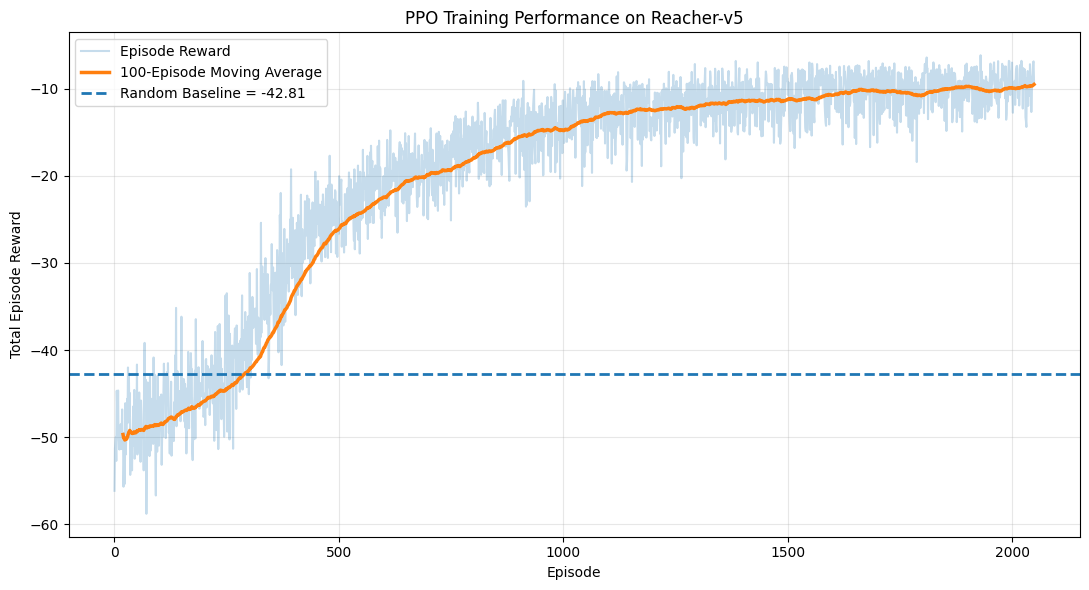

Saved plot: outputs\ppo_reward_learning_curve.png


In [31]:
# ============================================================
# PPO Episodic Reward and Convergence Curve
# ============================================================

reward_plot_df = final_episode_metrics.copy()

reward_plot_df["Reward Moving Average"] = (
    reward_plot_df["Total Reward"]
    .rolling(
        window=100,
        min_periods=20
    )
    .mean()
)


plt.figure(figsize=(11, 6))

# Individual episode rewards
plt.plot(
    reward_plot_df["Episode"],
    reward_plot_df["Total Reward"],
    alpha=0.25,
    label="Episode Reward"
)

# Moving average
plt.plot(
    reward_plot_df["Episode"],
    reward_plot_df["Reward Moving Average"],
    linewidth=2.5,
    label="100-Episode Moving Average"
)

# Random baseline
plt.axhline(
    random_baseline_reward,
    linestyle="--",
    linewidth=2,
    label=f"Random Baseline = {random_baseline_reward:.2f}"
)

plt.xlabel("Episode")
plt.ylabel("Total Episode Reward")

plt.title(
    "PPO Training Performance on Reacher-v5"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


reward_curve_path = (
    OUTPUT_DIR / "ppo_reward_learning_curve.png"
)

plt.savefig(
    reward_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved plot: {reward_curve_path}"
)

## 19. Target Distance and Control Efficiency

Episodic reward provides an overall measure of policy performance, but the Reacher reward combines both reaching accuracy and control effort.

To better understand what the PPO agent learned, the training results are therefore analyzed using two additional physical-performance measures:

- **Mean fingertip-to-target distance:** Measures how close the robotic arm remains to the target during an episode.
- **Mean control cost:** Measures the magnitude of the joint torques used by the agent.

An effective policy should reduce target distance while avoiding unnecessarily large control actions.

Performance during the first 100 training episodes is compared with the final 100 episodes and with the random-agent baseline.

In [32]:
# ============================================================
# Section 19: Physical Performance Analysis
# ============================================================

early_ppo = final_episode_metrics.head(100)
late_ppo = final_episode_metrics.tail(100)


physical_comparison = pd.DataFrame({

    "Policy": [
        "Random Baseline",
        "PPO - First 100 Episodes",
        "PPO - Final 100 Episodes"
    ],

    "Mean Reward": [
        baseline_df["Total Reward"].mean(),
        early_ppo["Total Reward"].mean(),
        late_ppo["Total Reward"].mean()
    ],

    "Mean Target Distance": [
        baseline_df["Mean Distance"].mean(),
        early_ppo["Mean Distance"].mean(),
        late_ppo["Mean Distance"].mean()
    ],

    "Mean Final Distance": [
        baseline_df["Final Distance"].mean(),
        early_ppo["Final Distance"].mean(),
        late_ppo["Final Distance"].mean()
    ],

    "Mean Control Cost": [
        baseline_df["Mean Control Cost"].mean(),
        early_ppo["Mean Control Cost"].mean(),
        late_ppo["Mean Control Cost"].mean()
    ]
})


print("=" * 80)
print("RANDOM VS EARLY PPO VS FINAL PPO")
print("=" * 80)

display(
    physical_comparison.round(4)
)

print("=" * 80)

RANDOM VS EARLY PPO VS FINAL PPO


,Policy,Mean Reward,Mean Target Distance,Mean Final Distance,Mean Control Cost
0,Random Baseline,-42.8072,0.1857,0.1669,0.6705
1,PPO - First 100 Episodes,-48.6280,0.1859,0.1667,0.7867
2,PPO - Final 100 Episodes,-9.5120,0.1459,0.1306,0.0443


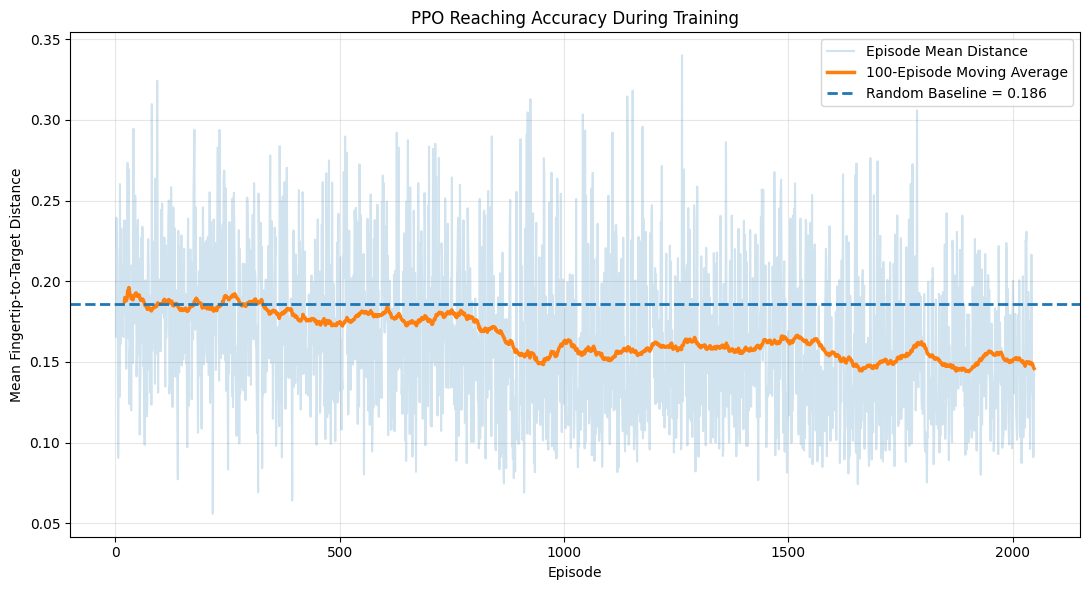

Saved plot: outputs\ppo_target_distance_curve.png


In [33]:
# ============================================================
# Fingertip-to-Target Distance Learning Curve
# ============================================================

distance_plot_df = final_episode_metrics.copy()

distance_plot_df["Distance Moving Average"] = (
    distance_plot_df["Mean Distance"]
    .rolling(
        window=100,
        min_periods=20
    )
    .mean()
)


plt.figure(figsize=(11, 6))

plt.plot(
    distance_plot_df["Episode"],
    distance_plot_df["Mean Distance"],
    alpha=0.20,
    label="Episode Mean Distance"
)

plt.plot(
    distance_plot_df["Episode"],
    distance_plot_df["Distance Moving Average"],
    linewidth=2.5,
    label="100-Episode Moving Average"
)

plt.axhline(
    baseline_df["Mean Distance"].mean(),
    linestyle="--",
    linewidth=2,
    label=(
        "Random Baseline = "
        f"{baseline_df['Mean Distance'].mean():.3f}"
    )
)

plt.xlabel("Episode")
plt.ylabel("Mean Fingertip-to-Target Distance")

plt.title(
    "PPO Reaching Accuracy During Training"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


distance_curve_path = (
    OUTPUT_DIR / "ppo_target_distance_curve.png"
)

plt.savefig(
    distance_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved plot: {distance_curve_path}"
)

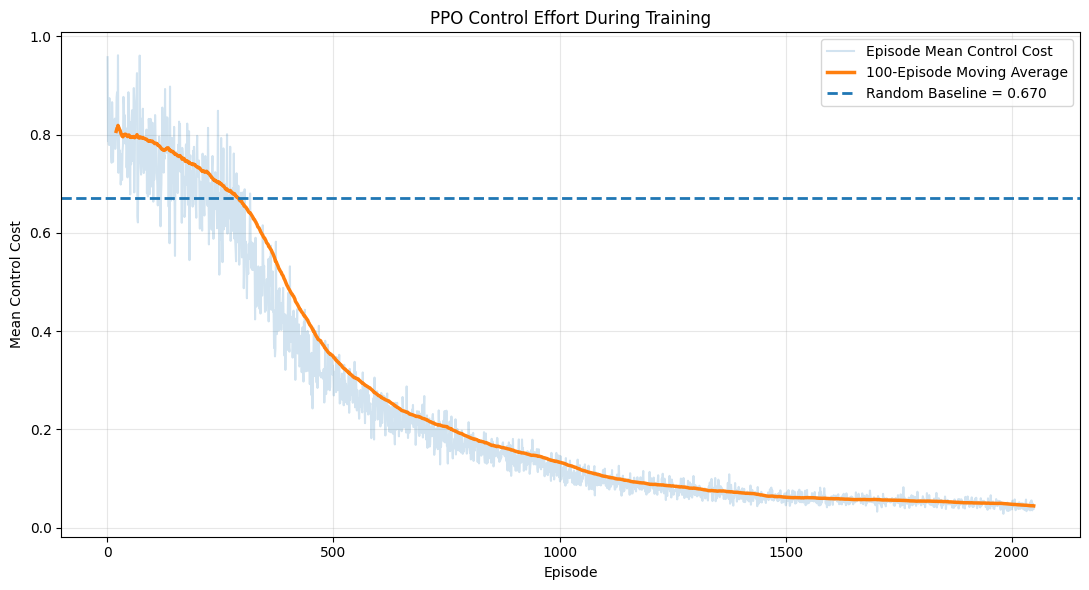

Saved plot: outputs\ppo_control_cost_curve.png


In [34]:
# ============================================================
# PPO Control-Cost Learning Curve
# ============================================================

control_plot_df = final_episode_metrics.copy()

control_plot_df["Control Cost Moving Average"] = (
    control_plot_df["Mean Control Cost"]
    .rolling(
        window=100,
        min_periods=20
    )
    .mean()
)


plt.figure(figsize=(11, 6))

plt.plot(
    control_plot_df["Episode"],
    control_plot_df["Mean Control Cost"],
    alpha=0.20,
    label="Episode Mean Control Cost"
)

plt.plot(
    control_plot_df["Episode"],
    control_plot_df["Control Cost Moving Average"],
    linewidth=2.5,
    label="100-Episode Moving Average"
)

plt.axhline(
    baseline_df["Mean Control Cost"].mean(),
    linestyle="--",
    linewidth=2,
    label=(
        "Random Baseline = "
        f"{baseline_df['Mean Control Cost'].mean():.3f}"
    )
)

plt.xlabel("Episode")
plt.ylabel("Mean Control Cost")

plt.title(
    "PPO Control Effort During Training"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


control_curve_path = (
    OUTPUT_DIR / "ppo_control_cost_curve.png"
)

plt.savefig(
    control_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved plot: {control_curve_path}"
)

## 20. PPO Training Stability Diagnostics

In addition to measuring task performance, PPO optimization diagnostics are analyzed to evaluate training stability.

The following measures are examined:

- **Value Loss:** Measures the error between the critic's value predictions and return targets.
- **Entropy:** Measures the uncertainty of the stochastic policy and provides an indication of exploration.
- **Clip Fraction:** Represents the fraction of policy updates affected by PPO clipping.
- **Approximate KL Divergence:** Provides an estimate of how much the policy changes during optimization.

Together, these diagnostics help determine whether the observed performance improvement occurred through a reasonably stable learning process.

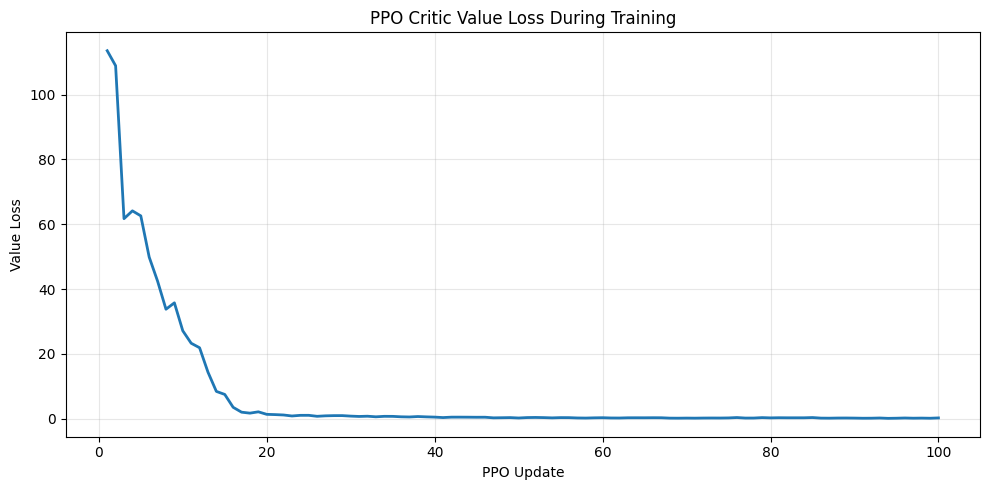

Saved plot: outputs\ppo_value_loss_curve.png


In [35]:
# ============================================================
# Section 20: PPO Critic Value-Loss Curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    final_update_metrics["Update"],
    final_update_metrics["Value Loss"],
    linewidth=2
)

plt.xlabel("PPO Update")
plt.ylabel("Value Loss")
plt.title("PPO Critic Value Loss During Training")

plt.grid(alpha=0.3)
plt.tight_layout()


value_loss_path = (
    OUTPUT_DIR / "ppo_value_loss_curve.png"
)

plt.savefig(
    value_loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {value_loss_path}")

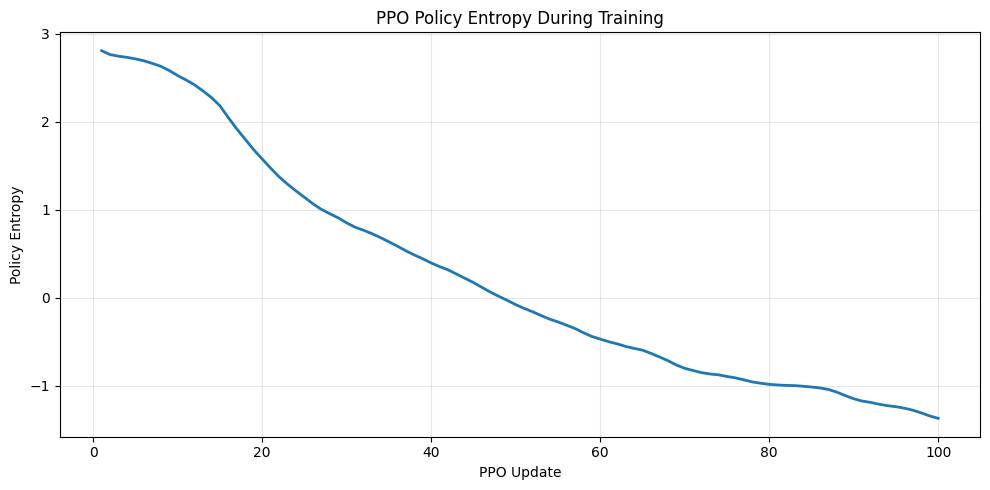

Saved plot: outputs\ppo_entropy_curve.png


In [36]:
# ============================================================
# PPO Policy Entropy During Training
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    final_update_metrics["Update"],
    final_update_metrics["Entropy"],
    linewidth=2
)

plt.xlabel("PPO Update")
plt.ylabel("Policy Entropy")
plt.title("PPO Policy Entropy During Training")

plt.grid(alpha=0.3)
plt.tight_layout()


entropy_path = (
    OUTPUT_DIR / "ppo_entropy_curve.png"
)

plt.savefig(
    entropy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {entropy_path}")

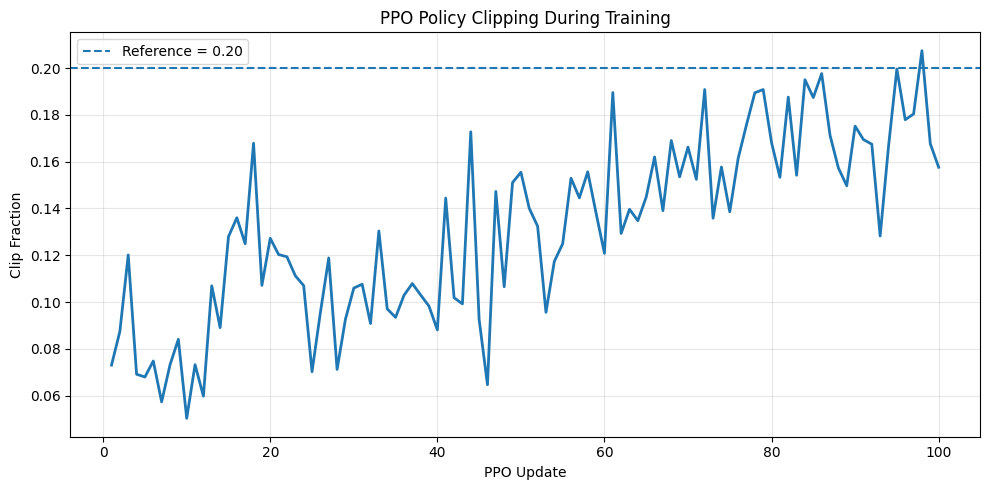

Saved plot: outputs\ppo_clip_fraction_curve.png


In [37]:
# ============================================================
# PPO Clip-Fraction Curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    final_update_metrics["Update"],
    final_update_metrics["Clip Fraction"],
    linewidth=2
)

plt.axhline(
    0.20,
    linestyle="--",
    label="Reference = 0.20"
)

plt.xlabel("PPO Update")
plt.ylabel("Clip Fraction")
plt.title("PPO Policy Clipping During Training")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


clip_fraction_path = (
    OUTPUT_DIR / "ppo_clip_fraction_curve.png"
)

plt.savefig(
    clip_fraction_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {clip_fraction_path}")

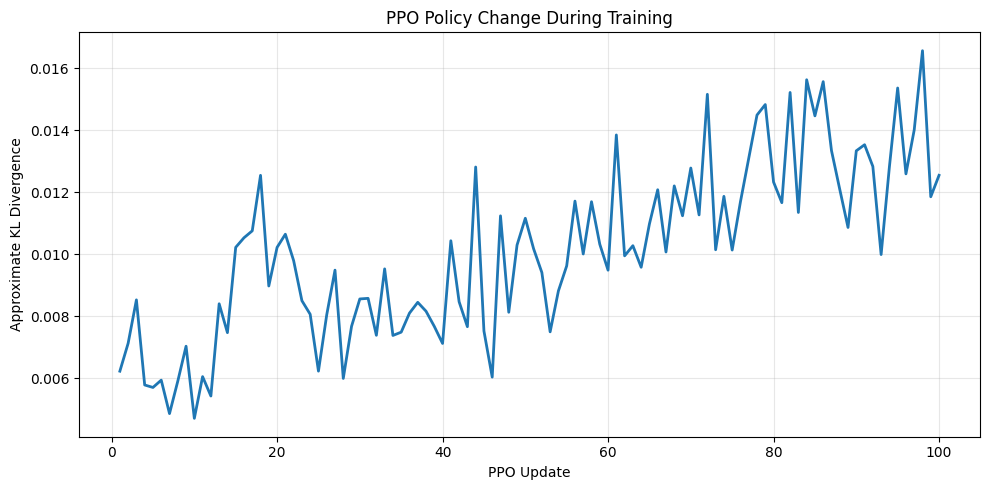

Saved plot: outputs\ppo_approx_kl_curve.png


In [38]:
# ============================================================
# PPO Approximate KL Divergence
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    final_update_metrics["Update"],
    final_update_metrics["Approx KL"],
    linewidth=2
)

plt.xlabel("PPO Update")
plt.ylabel("Approximate KL Divergence")
plt.title("PPO Policy Change During Training")

plt.grid(alpha=0.3)
plt.tight_layout()


kl_path = (
    OUTPUT_DIR / "ppo_approx_kl_curve.png"
)

plt.savefig(
    kl_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {kl_path}")

In [39]:
# ============================================================
# PPO Training Stability Summary
# ============================================================

first_10_updates = final_update_metrics.head(10)
final_10_updates = final_update_metrics.tail(10)


stability_summary = pd.DataFrame({

    "Metric": [
        "Mean Value Loss",
        "Mean Entropy",
        "Mean Clip Fraction",
        "Mean Approx KL"
    ],

    "First 10 Updates": [
        first_10_updates["Value Loss"].mean(),
        first_10_updates["Entropy"].mean(),
        first_10_updates["Clip Fraction"].mean(),
        first_10_updates["Approx KL"].mean()
    ],

    "Final 10 Updates": [
        final_10_updates["Value Loss"].mean(),
        final_10_updates["Entropy"].mean(),
        final_10_updates["Clip Fraction"].mean(),
        final_10_updates["Approx KL"].mean()
    ]
})


print("=" * 80)
print("PPO TRAINING STABILITY SUMMARY")
print("=" * 80)

display(
    stability_summary.round(6)
)

print("=" * 80)

PPO TRAINING STABILITY SUMMARY


,Metric,First 10 Updates,Final 10 Updates
0,Mean Value Loss,59.966440,0.162682
1,Mean Entropy,2.687103,-1.256948
2,Mean Clip Fraction,0.075732,0.172227
3,Mean Approx KL,0.006186,0.013216


## 21. Final Evaluation of the Trained PPO Policy

After training is complete, the learned PPO policy is evaluated without performing any additional neural-network updates.

The final model is tested over 100 new Reacher episodes using deterministic action selection. Instead of sampling actions from the Gaussian policy, the actor's learned mean action is used.

The evaluation measures:

- Mean episodic reward
- Reward variability
- Mean fingertip-to-target distance
- Mean final target distance
- Mean control cost
- Best and worst episode performance
- Reaching success rate

For this project, an episode is considered successful when the fingertip finishes within 0.05 distance units of the target.

Evaluation episodes use new random seeds so that performance is measured on target configurations that were not explicitly used during the final training sequence.

In [40]:
# ============================================================
# Section 21: Final PPO Policy Evaluation
# ============================================================

def evaluate_policy(
    env,
    model,
    num_episodes=100,
    seed_start=5000,
    success_threshold=0.05
):
    """
    Evaluate a trained PPO policy without additional learning.

    Deterministic actions are used during evaluation.
    """

    evaluation_results = []

    for episode in range(num_episodes):

        state, _ = env.reset(
            seed=seed_start + episode
        )

        terminated = False
        truncated = False

        episode_reward = 0.0
        distances = []
        control_costs = []
        steps = 0


        while not (terminated or truncated):

            # ------------------------------------------------
            # Use deterministic learned policy
            # ------------------------------------------------

            (
                env_action,
                raw_action,
                log_prob,
                state_value
            ) = select_action(
                model,
                state,
                deterministic=True
            )


            # ------------------------------------------------
            # Environment interaction
            # ------------------------------------------------

            next_state, reward, terminated, truncated, info = (
                env.step(env_action)
            )

            distance = np.linalg.norm(
                next_state[-2:]
            )

            control_cost = abs(
                info["reward_ctrl"]
            )


            # ------------------------------------------------
            # Record episode statistics
            # ------------------------------------------------

            episode_reward += reward
            distances.append(distance)
            control_costs.append(control_cost)

            steps += 1
            state = next_state


        final_distance = distances[-1]

        success = (
            final_distance <= success_threshold
        )


        evaluation_results.append({
            "Episode": episode + 1,
            "Total Reward": episode_reward,
            "Mean Distance": np.mean(distances),
            "Final Distance": final_distance,
            "Minimum Distance": np.min(distances),
            "Mean Control Cost": np.mean(control_costs),
            "Success": success,
            "Steps": steps
        })


    return pd.DataFrame(
        evaluation_results
    )

In [41]:
# ============================================================
# Run Final PPO Evaluation
# ============================================================

NUM_EVALUATION_EPISODES = 100
SUCCESS_THRESHOLD = 0.05


evaluation_env = gym.make(
    "Reacher-v5"
)


final_evaluation_df = evaluate_policy(
    env=evaluation_env,
    model=final_model,
    num_episodes=NUM_EVALUATION_EPISODES,
    seed_start=5000,
    success_threshold=SUCCESS_THRESHOLD
)


# ------------------------------------------------------------
# Evaluation summary
# ------------------------------------------------------------

evaluation_summary = pd.DataFrame({

    "Metric": [
        "Evaluation Episodes",
        "Mean Episode Reward",
        "Median Episode Reward",
        "Reward Standard Deviation",
        "Best Episode Reward",
        "Worst Episode Reward",
        "Mean Target Distance",
        "Mean Final Distance",
        "Mean Minimum Distance",
        "Mean Control Cost",
        "Success Threshold",
        "Success Rate"
    ],

    "Value": [
        len(final_evaluation_df),

        final_evaluation_df[
            "Total Reward"
        ].mean(),

        final_evaluation_df[
            "Total Reward"
        ].median(),

        final_evaluation_df[
            "Total Reward"
        ].std(),

        final_evaluation_df[
            "Total Reward"
        ].max(),

        final_evaluation_df[
            "Total Reward"
        ].min(),

        final_evaluation_df[
            "Mean Distance"
        ].mean(),

        final_evaluation_df[
            "Final Distance"
        ].mean(),

        final_evaluation_df[
            "Minimum Distance"
        ].mean(),

        final_evaluation_df[
            "Mean Control Cost"
        ].mean(),

        SUCCESS_THRESHOLD,

        final_evaluation_df[
            "Success"
        ].mean() * 100
    ]
})


print("=" * 80)
print("FINAL PPO POLICY EVALUATION")
print("=" * 80)

display(
    evaluation_summary.round(4)
)

print("-" * 80)

print(
    f"Random Baseline Mean Reward : "
    f"{baseline_df['Total Reward'].mean():.4f}"
)

print(
    f"Final Training Mean Reward  : "
    f"{final_episode_metrics['Total Reward'].tail(100).mean():.4f}"
)

print(
    f"Evaluation Mean Reward      : "
    f"{final_evaluation_df['Total Reward'].mean():.4f}"
)

print("=" * 80)


evaluation_env.close()

FINAL PPO POLICY EVALUATION


,Metric,Value
0,Evaluation Episodes,100.0000
1,Mean Episode Reward,-7.9557
2,Median Episode Reward,-7.5122
3,Reward Standard Deviation,2.0135
4,Best Episode Reward,-4.6289
5,Worst Episode Reward,-13.2632
6,Mean Target Distance,0.1488
7,Mean Final Distance,0.1255
8,Mean Minimum Distance,0.0623
9,Mean Control Cost,0.0103


--------------------------------------------------------------------------------
Random Baseline Mean Reward : -42.8072
Final Training Mean Reward  : -9.5120
Evaluation Mean Reward      : -7.9557


## 22. Final Performance Comparison

The trained PPO policy is compared with the random-action baseline using the same Reacher task.

The final evaluation demonstrates that the learned deterministic policy achieves substantially higher episodic reward while also reducing fingertip-to-target distance and control effort.

The binary success-rate measure uses a strict project-defined final-distance threshold of 0.05. Because the standard Reacher task uses a continuous reward rather than a binary success condition, episodic reward and target-distance measures are treated as the primary indicators of performance.

In [42]:
# ============================================================
# Section 22: Save Final Evaluation Results
# ============================================================

evaluation_metrics_path = (
    OUTPUT_DIR / "ppo_evaluation_episode_metrics.csv"
)

evaluation_summary_path = (
    OUTPUT_DIR / "ppo_evaluation_summary.csv"
)


final_evaluation_df.to_csv(
    evaluation_metrics_path,
    index=False
)

evaluation_summary.to_csv(
    evaluation_summary_path,
    index=False
)


print("=" * 70)
print("FINAL EVALUATION ARTIFACTS SAVED")
print("=" * 70)

print(f"Episode Metrics : {evaluation_metrics_path}")
print(f"Summary Metrics : {evaluation_summary_path}")

print("=" * 70)

FINAL EVALUATION ARTIFACTS SAVED
Episode Metrics : outputs\ppo_evaluation_episode_metrics.csv
Summary Metrics : outputs\ppo_evaluation_summary.csv


In [43]:
# ============================================================
# Random Baseline vs. Final PPO Evaluation
# ============================================================

final_comparison = pd.DataFrame({

    "Metric": [
        "Mean Episode Reward",
        "Median Episode Reward",
        "Reward Standard Deviation",
        "Mean Target Distance",
        "Mean Final Distance",
        "Mean Control Cost"
    ],

    "Random Baseline": [
        baseline_df["Total Reward"].mean(),
        baseline_df["Total Reward"].median(),
        baseline_df["Total Reward"].std(),
        baseline_df["Mean Distance"].mean(),
        baseline_df["Final Distance"].mean(),
        baseline_df["Mean Control Cost"].mean()
    ],

    "Trained PPO": [
        final_evaluation_df["Total Reward"].mean(),
        final_evaluation_df["Total Reward"].median(),
        final_evaluation_df["Total Reward"].std(),
        final_evaluation_df["Mean Distance"].mean(),
        final_evaluation_df["Final Distance"].mean(),
        final_evaluation_df["Mean Control Cost"].mean()
    ]
})


print("=" * 80)
print("RANDOM BASELINE VS TRAINED PPO")
print("=" * 80)

display(
    final_comparison.round(4)
)

print("=" * 80)


comparison_path = (
    OUTPUT_DIR / "random_vs_ppo_comparison.csv"
)

final_comparison.to_csv(
    comparison_path,
    index=False
)

print(
    f"Saved comparison: {comparison_path}"
)

RANDOM BASELINE VS TRAINED PPO


,Metric,Random Baseline,Trained PPO
0,Mean Episode Reward,-42.8072,-7.9557
1,Median Episode Reward,-42.4546,-7.5122
2,Reward Standard Deviation,4.1327,2.0135
3,Mean Target Distance,0.1857,0.1488
4,Mean Final Distance,0.1669,0.1255
5,Mean Control Cost,0.6705,0.0103


Saved comparison: outputs\random_vs_ppo_comparison.csv


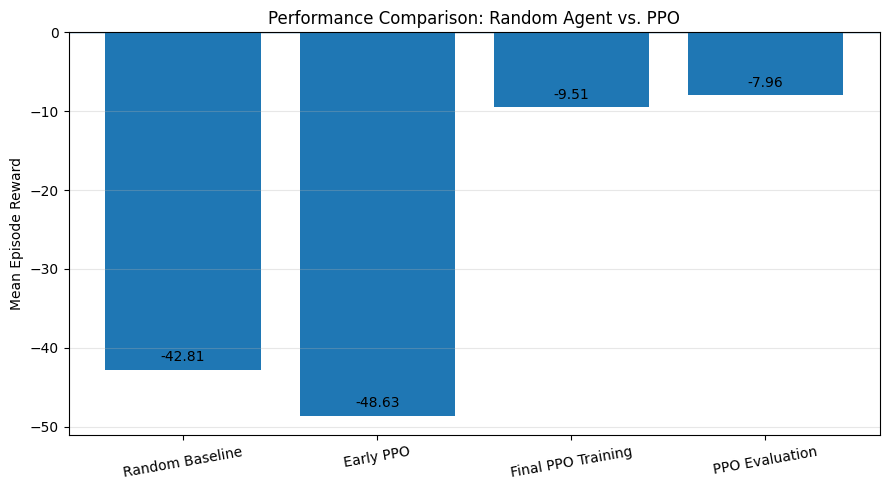

Saved plot: outputs\random_vs_ppo_reward_comparison.png


In [44]:
# ============================================================
# Final Random vs. PPO Reward Comparison
# ============================================================

reward_comparison_plot = pd.DataFrame({

    "Policy": [
        "Random Baseline",
        "Early PPO",
        "Final PPO Training",
        "PPO Evaluation"
    ],

    "Mean Reward": [
        baseline_df["Total Reward"].mean(),
        final_episode_metrics["Total Reward"].head(100).mean(),
        final_episode_metrics["Total Reward"].tail(100).mean(),
        final_evaluation_df["Total Reward"].mean()
    ]
})


plt.figure(figsize=(9, 5))

bars = plt.bar(
    reward_comparison_plot["Policy"],
    reward_comparison_plot["Mean Reward"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Mean Episode Reward")
plt.title(
    "Performance Comparison: Random Agent vs. PPO"
)

plt.xticks(rotation=10)

plt.grid(
    axis="y",
    alpha=0.3
)


# Add values above/below bars
for bar, value in zip(
    bars,
    reward_comparison_plot["Mean Reward"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.7,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()


comparison_plot_path = (
    OUTPUT_DIR / "random_vs_ppo_reward_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"Saved plot: {comparison_plot_path}"
)

## 23. Save the Trained PPO Model

The final trained actor-critic network is saved as a PyTorch checkpoint.

The checkpoint stores the learned neural-network parameters together with the optimizer state and important project configuration values. This allows the trained policy to be restored later without repeating the complete training process.

In [45]:
# ============================================================
# Section 23: Save Final PPO Model Checkpoint
# ============================================================

CHECKPOINT_DIR = Path("checkpoints")

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


checkpoint_path = (
    CHECKPOINT_DIR / "ppo_reacher_final.pt"
)


torch.save({

    "model_state_dict":
        final_model.state_dict(),

    "optimizer_state_dict":
        final_optimizer.state_dict(),

    "state_dim":
        state_dim,

    "action_dim":
        action_dim,

    "seed":
        SEED,

    "learning_rate":
        LEARNING_RATE,

    "gamma":
        GAMMA,

    "gae_lambda":
        GAE_LAMBDA,

    "clip_epsilon":
        CLIP_EPSILON,

    "rollout_steps":
        ROLLOUT_STEPS,

    "minibatch_size":
        MINIBATCH_SIZE,

    "ppo_epochs":
        PPO_EPOCHS,

    "training_updates":
        FULL_TRAINING_UPDATES,

    "environment_steps":
        FULL_TRAINING_UPDATES * ROLLOUT_STEPS,

    "training_runtime_seconds":
        training_runtime_seconds

}, checkpoint_path)


print("=" * 70)
print("FINAL PPO CHECKPOINT SAVED")
print("=" * 70)

print(
    f"Checkpoint : {checkpoint_path}"
)

print(
    f"File Size  : "
    f"{checkpoint_path.stat().st_size / 1024:.2f} KB"
)

print("=" * 70)

FINAL PPO CHECKPOINT SAVED
Checkpoint : checkpoints\ppo_reacher_final.pt
File Size  : 132.20 KB


## 24. Visual Demonstration of the Trained PPO Agent

A visual evaluation is performed using the trained PPO policy in a rendered MuJoCo `Reacher-v5` environment.

The policy operates deterministically during the demonstration so that the visualization reflects the learned behavior rather than additional exploration noise.

Frames from the evaluation episode are captured to illustrate how the robotic arm moves toward the target. The complete episode is also recorded as a short video for use in the project presentation.

In [46]:
# ============================================================
# Section 24: Capture Trained PPO Demonstration Episode
# ============================================================

demo_env = gym.make(
    "Reacher-v5",
    render_mode="rgb_array"
)

DEMO_SEED = 6000

state, _ = demo_env.reset(
    seed=DEMO_SEED
)

demo_frames = []

demo_reward = 0.0
demo_distances = []
demo_control_costs = []

terminated = False
truncated = False
step_number = 0


# Capture initial frame
initial_frame = demo_env.render()
demo_frames.append(initial_frame)


while not (terminated or truncated):

    # --------------------------------------------------------
    # Deterministic trained PPO action
    # --------------------------------------------------------

    (
        env_action,
        raw_action,
        log_prob,
        state_value
    ) = select_action(
        final_model,
        state,
        deterministic=True
    )


    # --------------------------------------------------------
    # Apply action
    # --------------------------------------------------------

    next_state, reward, terminated, truncated, info = (
        demo_env.step(env_action)
    )


    # --------------------------------------------------------
    # Capture rendered frame
    # --------------------------------------------------------

    frame = demo_env.render()

    demo_frames.append(
        frame
    )


    # --------------------------------------------------------
    # Record metrics
    # --------------------------------------------------------

    distance = np.linalg.norm(
        next_state[-2:]
    )

    control_cost = abs(
        info["reward_ctrl"]
    )

    demo_reward += reward
    demo_distances.append(distance)
    demo_control_costs.append(control_cost)

    step_number += 1
    state = next_state


print("=" * 70)
print("TRAINED PPO DEMONSTRATION")
print("=" * 70)

print(f"Demo Seed             : {DEMO_SEED}")
print(f"Episode Steps         : {step_number}")
print(f"Captured Frames       : {len(demo_frames)}")
print(f"Total Reward          : {demo_reward:.4f}")
print(f"Mean Target Distance  : {np.mean(demo_distances):.4f}")
print(f"Final Target Distance : {demo_distances[-1]:.4f}")
print(f"Minimum Distance      : {np.min(demo_distances):.4f}")
print(f"Mean Control Cost     : {np.mean(demo_control_costs):.4f}")

print("=" * 70)


demo_env.close()

TRAINED PPO DEMONSTRATION
Demo Seed             : 6000
Episode Steps         : 50
Captured Frames       : 51
Total Reward          : -7.6089
Mean Target Distance  : 0.1400
Final Target Distance : 0.0892
Minimum Distance      : 0.0661
Mean Control Cost     : 0.0122


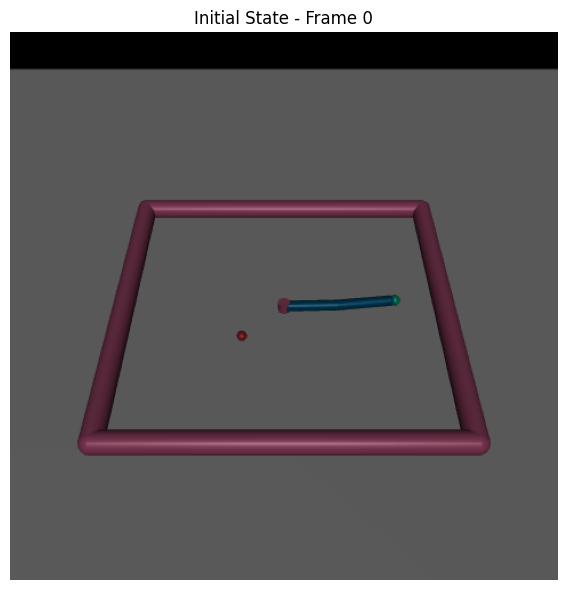

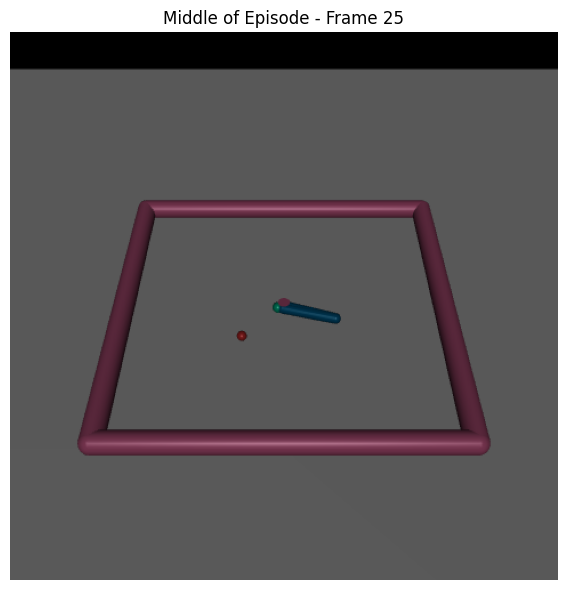

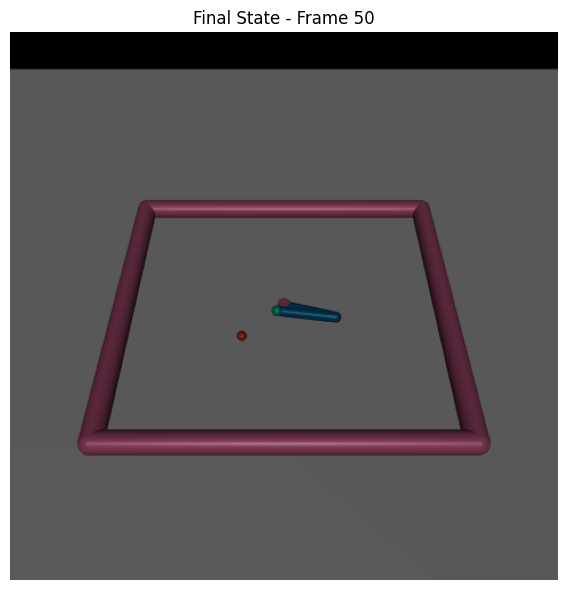

In [47]:
# ============================================================
# Display Key Frames from the PPO Demonstration
# ============================================================

frame_indices = {
    "Initial State": 0,
    "Middle of Episode": len(demo_frames) // 2,
    "Final State": len(demo_frames) - 1
}


for title, frame_index in frame_indices.items():

    plt.figure(figsize=(6, 6))

    plt.imshow(
        demo_frames[frame_index]
    )

    plt.title(
        f"{title} - Frame {frame_index}"
    )

    plt.axis("off")
    plt.tight_layout()

    plt.show()

In [48]:
# ============================================================
# Save PPO Demonstration Screenshots
# ============================================================

SCREENSHOT_DIR = Path("screenshots")

SCREENSHOT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


screenshot_frames = {
    "ppo_demo_initial.png": demo_frames[0],
    "ppo_demo_middle.png": demo_frames[len(demo_frames) // 2],
    "ppo_demo_final.png": demo_frames[-1]
}


for filename, frame in screenshot_frames.items():

    filepath = (
        SCREENSHOT_DIR / filename
    )

    plt.imsave(
        filepath,
        frame
    )

    print(
        f"Saved: {filepath}"
    )

Saved: screenshots\ppo_demo_initial.png
Saved: screenshots\ppo_demo_middle.png
Saved: screenshots\ppo_demo_final.png


In [50]:
%pip install "imageio[ffmpeg]"

   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/31.2 MB 9.6 MB/s eta 0:00:04
   ----- ---------------------------------- 4.2/31.2 MB 12.0 MB/s eta 0:00:03
   --------- ------------------------------ 7.6/31.2 MB 13.4 MB/s eta 0:00:02
   -------------- ------------------------- 11.3/31.2 MB 14.7 MB/s eta 0:00:02
   ------------------ --------------------- 14.7/31.2 MB 14.7 MB/s eta 0:00:02
   ----------------------- ---------------- 18.4/31.2 MB 15.2 MB/s eta 0:00:01
   ------------------------ --------------- 19.4/31.2 MB 13.6 MB/s eta 0:00:01
   ----------------------------- ---------- 22.8/31.2 MB 14.3 MB/s eta 0:00:01
   ----------------------------------- ---- 27.5/31.2 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------  31.2/31.2 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 14.7 MB/s  0:00:0


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import imageio
import imageio_ffmpeg

print("ImageIO version       :", imageio.__version__)
print("ImageIO-FFmpeg version:", imageio_ffmpeg.__version__)
print("FFmpeg executable     :", imageio_ffmpeg.get_ffmpeg_exe())

ImageIO version       : 2.37.4
ImageIO-FFmpeg version: 0.6.0
FFmpeg executable     : c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [52]:
# ============================================================
# Create PPO Demonstration Video
# ============================================================

import imageio.v2 as imageio


DEMO_DIR = Path("demo")

DEMO_DIR.mkdir(
    parents=True,
    exist_ok=True
)


demo_video_path = (
    DEMO_DIR / "ppo_reacher_trained_agent.mp4"
)


imageio.mimsave(
    demo_video_path,
    demo_frames,
    fps=15
)


print("=" * 70)
print("PPO DEMONSTRATION VIDEO CREATED")
print("=" * 70)

print(
    f"Video Path : {demo_video_path}"
)

print(
    f"File Size  : "
    f"{demo_video_path.stat().st_size / 1024:.2f} KB"
)

print("=" * 70)

PPO DEMONSTRATION VIDEO CREATED
Video Path : demo\ppo_reacher_trained_agent.mp4
File Size  : 10.57 KB


## 25. Presentation Demonstration

The trained-agent episode is converted into a slower presentation-friendly video.

The original MuJoCo simulation contains 51 rendered frames. A playback rate of five frames per second produces a demonstration of approximately 10 seconds, allowing the robotic-arm movement to be observed more clearly during the recorded presentation.

In [53]:
# ============================================================
# Section 25: Create Presentation-Friendly PPO Demo
# ============================================================

presentation_demo_path = (
    DEMO_DIR / "ppo_reacher_presentation_demo.mp4"
)

imageio.mimsave(
    presentation_demo_path,
    demo_frames,
    fps=5
)

presentation_duration = (
    len(demo_frames) / 5
)

print("=" * 70)
print("PRESENTATION DEMO CREATED")
print("=" * 70)

print(f"Video Path       : {presentation_demo_path}")
print(f"Frames           : {len(demo_frames)}")
print(f"Playback FPS     : 5")
print(f"Approx. Duration : {presentation_duration:.2f} seconds")

print(
    f"File Size        : "
    f"{presentation_demo_path.stat().st_size / 1024:.2f} KB"
)

print("=" * 70)

PRESENTATION DEMO CREATED
Video Path       : demo\ppo_reacher_presentation_demo.mp4
Frames           : 51
Playback FPS     : 5
Approx. Duration : 10.20 seconds
File Size        : 13.32 KB


In [54]:
# ============================================================
# Display Trained PPO Demo Inside Notebook
# ============================================================

from IPython.display import Video, display

display(
    Video(
        str(presentation_demo_path),
        embed=True,
        width=640
    )
)

In [55]:
# ============================================================
# Save Demonstration Metrics
# ============================================================

demo_summary = pd.DataFrame({
    "Metric": [
        "Demo Seed",
        "Episode Steps",
        "Total Reward",
        "Mean Target Distance",
        "Final Target Distance",
        "Minimum Target Distance",
        "Mean Control Cost"
    ],

    "Value": [
        DEMO_SEED,
        step_number,
        demo_reward,
        np.mean(demo_distances),
        demo_distances[-1],
        np.min(demo_distances),
        np.mean(demo_control_costs)
    ]
})

demo_summary_path = (
    OUTPUT_DIR / "ppo_demo_summary.csv"
)

demo_summary.to_csv(
    demo_summary_path,
    index=False
)

print("=" * 70)
print("PPO DEMONSTRATION SUMMARY")
print("=" * 70)

display(
    demo_summary.round(4)
)

print(f"Saved: {demo_summary_path}")

print("=" * 70)

PPO DEMONSTRATION SUMMARY


,Metric,Value
0,Demo Seed,6000.0000
1,Episode Steps,50.0000
2,Total Reward,-7.6089
3,Mean Target Distance,0.1400
4,Final Target Distance,0.0892
5,Minimum Target Distance,0.0661
6,Mean Control Cost,0.0122


Saved: outputs\ppo_demo_summary.csv


## 26. Final Project Artifact Inventory

The completed reinforcement learning project generates a collection of reproducible artifacts including training metrics, evaluation results, visualizations, model checkpoints, screenshots, and a recorded agent demonstration.

The final artifact inventory verifies that the files required to analyze, reproduce, document, and present the project were successfully generated.

In [56]:
# ============================================================
# Section 26: Final Project Artifact Inventory
# ============================================================

project_artifacts = [

    # Notebook / project documentation
    ("Notebook", Path("RL_PPO_Reacher_Project.ipynb")),
    ("README", Path("README.md")),

    # Model
    ("Final PPO Checkpoint",
     Path("checkpoints/ppo_reacher_final.pt")),

    # Random baseline
    ("Random Baseline Metrics",
     Path("outputs/random_baseline_metrics.csv")),

    ("Random Baseline Summary",
     Path("outputs/random_baseline_summary.csv")),

    ("Random Baseline Plot",
     Path("outputs/random_baseline_rewards.png")),

    # PPO training
    ("PPO Episode Metrics",
     Path("outputs/ppo_training_episode_metrics.csv")),

    ("PPO Update Metrics",
     Path("outputs/ppo_training_update_metrics.csv")),

    ("PPO Training Summary",
     Path("outputs/ppo_training_summary.csv")),

    ("PPO Reward Curve",
     Path("outputs/ppo_reward_learning_curve.png")),

    ("PPO Target Distance Curve",
     Path("outputs/ppo_target_distance_curve.png")),

    ("PPO Control Cost Curve",
     Path("outputs/ppo_control_cost_curve.png")),

    ("PPO Value Loss Curve",
     Path("outputs/ppo_value_loss_curve.png")),

    ("PPO Entropy Curve",
     Path("outputs/ppo_entropy_curve.png")),

    ("PPO Clip Fraction Curve",
     Path("outputs/ppo_clip_fraction_curve.png")),

    ("PPO Approx KL Curve",
     Path("outputs/ppo_approx_kl_curve.png")),

    # Evaluation
    ("PPO Evaluation Metrics",
     Path("outputs/ppo_evaluation_episode_metrics.csv")),

    ("PPO Evaluation Summary",
     Path("outputs/ppo_evaluation_summary.csv")),

    ("Random vs PPO Comparison",
     Path("outputs/random_vs_ppo_comparison.csv")),

    ("Reward Comparison Plot",
     Path("outputs/random_vs_ppo_reward_comparison.png")),

    # Demo
    ("Demo Summary",
     Path("outputs/ppo_demo_summary.csv")),

    ("Initial Demo Screenshot",
     Path("screenshots/ppo_demo_initial.png")),

    ("Middle Demo Screenshot",
     Path("screenshots/ppo_demo_middle.png")),

    ("Final Demo Screenshot",
     Path("screenshots/ppo_demo_final.png")),

    ("Raw PPO Demo",
     Path("demo/ppo_reacher_trained_agent.mp4")),

    ("Presentation PPO Demo",
     Path("demo/ppo_reacher_presentation_demo.mp4")),
]


artifact_rows = []

for artifact_name, artifact_path in project_artifacts:

    exists = artifact_path.exists()

    size_kb = (
        artifact_path.stat().st_size / 1024
        if exists
        else 0
    )

    artifact_rows.append({
        "Artifact": artifact_name,
        "Exists": exists,
        "Size KB": size_kb
    })


artifact_inventory_df = pd.DataFrame(
    artifact_rows
)


print("=" * 85)
print("FINAL PROJECT ARTIFACT INVENTORY")
print("=" * 85)

display(
    artifact_inventory_df.round(2)
)

print("-" * 85)

print(
    f"Artifacts Found : "
    f"{artifact_inventory_df['Exists'].sum()}"
)

print(
    f"Artifacts Listed: "
    f"{len(artifact_inventory_df)}"
)

print("=" * 85)

FINAL PROJECT ARTIFACT INVENTORY


,Artifact,Exists,Size KB
0,Notebook,True,1030.98
1,README,True,0.00
2,Final PPO Checkpoint,True,132.20
3,Random Baseline Metrics,True,8.32
4,Random Baseline Summary,True,0.38
5,Random Baseline Plot,True,286.36
6,PPO Episode Metrics,True,192.07
7,PPO Update Metrics,True,13.89
8,PPO Training Summary,True,0.48
9,PPO Reward Curve,True,277.40


-------------------------------------------------------------------------------------
Artifacts Found : 26
Artifacts Listed: 26


## 27. Final Project Result

The completed experiment demonstrates that PPO successfully learned a continuous-control policy for the MuJoCo Reacher-v5 robotic arm.

The trained policy substantially outperformed the random-action baseline, improved reaching accuracy, reduced unnecessary control effort, and maintained strong performance during evaluation on new environment initializations.

The results support the original project hypothesis that Proximal Policy Optimization can learn an effective and stable policy for continuous robotic-arm control.

In [57]:
# ============================================================
# Section 27: Final Project Result Summary
# ============================================================

baseline_reward = baseline_df[
    "Total Reward"
].mean()

evaluation_reward = final_evaluation_df[
    "Total Reward"
].mean()

baseline_distance = baseline_df[
    "Mean Distance"
].mean()

evaluation_distance = final_evaluation_df[
    "Mean Distance"
].mean()

baseline_control = baseline_df[
    "Mean Control Cost"
].mean()

evaluation_control = final_evaluation_df[
    "Mean Control Cost"
].mean()


reward_gain = (
    evaluation_reward - baseline_reward
)

distance_reduction_pct = (
    (baseline_distance - evaluation_distance)
    / baseline_distance
    * 100
)

control_reduction_pct = (
    (baseline_control - evaluation_control)
    / baseline_control
    * 100
)


print("=" * 75)
print("FINAL PPO PROJECT RESULT")
print("=" * 75)

print(
    f"Random Baseline Reward       : "
    f"{baseline_reward:.4f}"
)

print(
    f"Trained PPO Evaluation Reward: "
    f"{evaluation_reward:.4f}"
)

print(
    f"Reward Improvement           : "
    f"+{reward_gain:.4f}"
)

print("-" * 75)

print(
    f"Random Mean Target Distance  : "
    f"{baseline_distance:.4f}"
)

print(
    f"PPO Mean Target Distance     : "
    f"{evaluation_distance:.4f}"
)

print(
    f"Target Distance Reduction    : "
    f"{distance_reduction_pct:.2f}%"
)

print("-" * 75)

print(
    f"Random Mean Control Cost     : "
    f"{baseline_control:.4f}"
)

print(
    f"PPO Mean Control Cost        : "
    f"{evaluation_control:.4f}"
)

print(
    f"Control Cost Reduction       : "
    f"{control_reduction_pct:.2f}%"
)

print("-" * 75)

print(
    f"Evaluation Success Rate      : "
    f"{final_evaluation_df['Success'].mean() * 100:.2f}% "
    f"(threshold = {SUCCESS_THRESHOLD})"
)

print(
    f"Training Environment Steps   : "
    f"{FULL_TRAINING_UPDATES * ROLLOUT_STEPS:,}"
)

print(
    f"Training Runtime             : "
    f"{training_runtime_seconds:.2f} seconds"
)

print("=" * 75)

print(
    "\nConclusion: PPO successfully learned a substantially "
    "better continuous-control policy than the random baseline."
)

FINAL PPO PROJECT RESULT
Random Baseline Reward       : -42.8072
Trained PPO Evaluation Reward: -7.9557
Reward Improvement           : +34.8515
---------------------------------------------------------------------------
Random Mean Target Distance  : 0.1857
PPO Mean Target Distance     : 0.1488
Target Distance Reduction    : 19.87%
---------------------------------------------------------------------------
Random Mean Control Cost     : 0.6705
PPO Mean Control Cost        : 0.0103
Control Cost Reduction       : 98.46%
---------------------------------------------------------------------------
Evaluation Success Rate      : 10.00% (threshold = 0.05)
Training Environment Steps   : 102,400
Training Runtime             : 129.50 seconds

Conclusion: PPO successfully learned a substantially better continuous-control policy than the random baseline.
